# Trajectory KD vs WT

In [1]:
here::i_am("revisions/04_TEomes_interaction/02_export_table.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(destiny))
suppressPackageStartupMessages(library(tradeSeq))
suppressPackageStartupMessages(library(slingshot))
suppressPackageStartupMessages(library(ArchR))
suppressPackageStartupMessages(library(BiocParallel))

suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(scales))
suppressPackageStartupMessages(library(ComplexHeatmap))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 24

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM
set.seed(42)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”

                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | 

In [2]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated_v2.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'results/rna_atac/trajectory/v3/rna_sce.rds')

args$logFC_thr = 0.25
args$FDR_thr = 0.05

# outdir
args$outdir = file.path(io$basedir, 'results/revisions/04_TEomes_interaction/')

In [3]:
# RNA
condRes = fread(file.path(args$outdir, 'condRes_RNA_v2.txt.gz'))

In [6]:
fwrite(condRes, file.path(args$outdir, 'Stable_invitro_trajectory_KDvWT_DEGs.csv'), sep = ',')

In [24]:
# ATAC
condRes = fread(file.path(args$outdir, 'condRes_ATAC_v2.txt.gz')) %>% setnames('gene', 'region')

In [8]:
group.dt = fread(file.path(args$outdir, 'atac_groups.txt.gz'))

In [10]:
T_bed = fread('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_Peaks_ChIP_BraGFP_pileup40.bed.gz') %>%
    setnames(c('chr', 'start','end', 'name'))
Eomes_bed = fread('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_Peaks_ChIP_EoGFP_pileup120.bed.gz') %>%
    setnames(c('chr', 'start','end', 'name'))

In [11]:
Eomes_gr = makeGRangesFromDataFrame(Eomes_bed)
T_gr = makeGRangesFromDataFrame(T_bed)

In [12]:
input_region= group.dt$region
gr <- GRanges(c(str_split(input_region, ":") %>% map_chr(1)), 
    IRanges(start = as.numeric(str_split(str_split(input_region, 
                        ":") %>% map_chr(2), "-") %>% map_chr(1)), 
            end = as.numeric(str_split(str_split(input_region, 
                      ":") %>% map_chr(2), "-") %>% map_chr(2))), strand = "+")

gr

GRanges object with 7040 ranges and 0 metadata columns:
         seqnames              ranges strand
            <Rle>           <IRanges>  <Rle>
     [1]     chr9   46913091-46913691      +
     [2]     chr1 180888483-180889083      +
     [3]    chr14   63359208-63359808      +
     [4]    chr14 121779637-121780237      +
     [5]    chr14   23902737-23903337      +
     ...      ...                 ...    ...
  [7036]    chr19   37995436-37996036      +
  [7037]     chr4 141337801-141338401      +
  [7038]     chr7 141148478-141149078      +
  [7039]     chr2 165201621-165202221      +
  [7040]     chr4 156063749-156064349      +
  -------
  seqinfo: 20 sequences from an unspecified genome; no seqlengths

In [18]:
overlap = data.table(region = input_region) %>%
    .[, Eomes_bound := ifelse(.I %in% queryHits(findOverlaps(gr, Eomes_gr, type = 'any', minoverlap = 100)), 'Bound', 'Not bound')] %>%
    .[, T_bound := ifelse(.I %in% queryHits(findOverlaps(gr, T_gr, type = 'any', minoverlap = 100)), 'Bound', 'Not bound')] %>% 
    melt(id.vars = 'region') %>%
    merge(., group.dt, by = 'region') %>% 
    .[,group := factor(group, levels = c(1,2,3,4,5))] %>% 
    .[order(group)] %>% 
    .[,variable := gsub('_', ' ', variable)]

In [23]:
head(condRes)

peak,waldStat,df,pvalue,padj,sig
<chr>,<dbl>,<int>,<dbl>,<dbl>,<lgl>
chr9:46913091-46913691,151.26551,8,0,0,TRUE
chr1:180888483-180889083,150.85298,2,0,0,TRUE
chr14:63359208-63359808,126.81774,8,0,0,TRUE
chr14:121779637-121780237,121.73574,8,0,0,TRUE
chr14:23902737-23903337,103.34392,8,0,0,TRUE
chr16:11469982-11470582,96.77364,6,0,0,TRUE


In [34]:
combined = merge(condRes, overlap, by = 'region', all.x = T)

In [35]:
fwrite(combined, file.path(args$outdir, 'Stable_invitro_trajectory_KDvWT_DARs.csv'), sep = ',')

In [32]:
######
#### Find variable peaks
######

# Load RNA sceGAM
sceGAM_RNA = readRDS(file.path(args$outdir, 'sceGAM.rds'))

# load sce atac
atac.sce = readRDS(args$peakmtx)[, colnames(sceGAM_RNA)] # keep only cells from relevant trajectory
colData(atac.sce) = meta2[match(colnames(sceGAM_RNA), cell)] %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()
atac.sce = as(atac.sce, 'SingleCellExperiment')
assayNames(atac.sce) <- "counts"

# load mofa factors
mofa = fread(file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/mofa/MOFA_factors.txt.gz')) %>% 
    .[match(colnames(atac.sce), cell),] %>% 
    as.data.frame() %>% tibble::column_to_rownames('cell') %>% 
    as.matrix

In [38]:
## First cluster cells at high resolution (replicating meta cells)
# Convert to Seurat
suppressPackageStartupMessages(library(Seurat))
seurat = CreateSeuratObject(counts = counts(atac.sce))
seurat[["mofa"]] <- CreateDimReducObject(embeddings = mofa, key = "mofa_", assay = DefaultAssay(seurat))

# First find high resolution clusters across the whole WT dataset
seurat <- FindNeighbors(seurat, reduction  = 'mofa')
seurat <- FindClusters(seurat, resolution = 1.5)
paste0('Number of Clusters: ', length(unique(Idents(seurat))))

# Pseudobulk ATAC by those clusters
atac.pb = aggregateAcrossCells(atac.sce, id=Idents(seurat), statistics="sum", use.assay.type="counts",  BPPARAM = BPPARAM)

# Normalise
assay(atac.pb,"logcounts") <- log(1e6*(sweep(assay(atac.pb),2,colSums(assay(atac.pb),na.rm=T),"/"))+1)

# Get HVGs
decomp <- modelGeneVar(atac.pb, BPPARAM = MulticoreParam(16)) # [expression$gene,]
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% 
    as.data.table(., keep.rownames=T) 

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 7176
Number of edges: 223221

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7092
Number of communities: 15
Elapsed time: 0 seconds


Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via the L'Ecuyer-CMRG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”


[1] "Number of Clusters: 15"

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


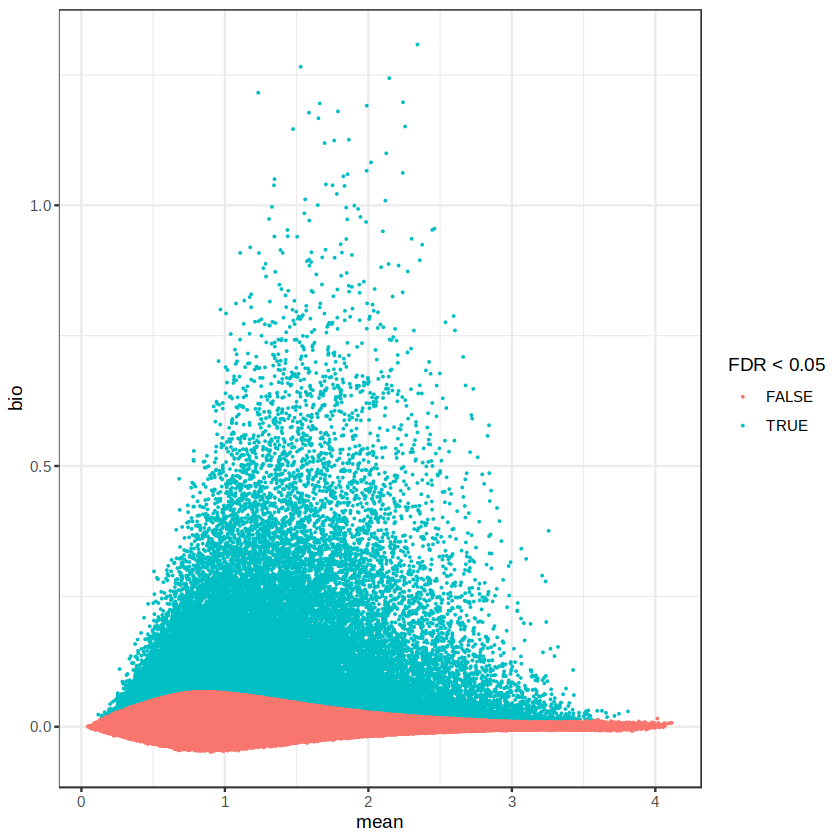

In [39]:
ggplot(hvgs, aes(mean, bio, color = FDR < 0.05)) + 
    geom_point(size = 0.02) + 
    theme_bw()

In [45]:
nrow(hvgs[FDR< 0.05])

[1] 40709

In [46]:
summary(colnames(atac.sce) == colnames(sceGAM))
summary(hvgs$rn %in% rownames(atac.sce))

   Mode    TRUE 
logical    7176 

   Mode    TRUE 
logical  234908 

In [55]:
class(atac.sce$replicate)

[1] "character"

In [57]:
# Export files to run as Rscript
R_script_list = list(cells = colnames(atac.sce),
                     peaks = rownames(atac.sce),
                     peak_stats = hvgs,
                     genotype = atac.sce$genotype,
                     replicate = atac.sce$replicate,
                     pseudotime = pseudotime,
                     weight = weight)

In [59]:
# Get pseudotime and weights from RNA sceGAM (To make sure the exact same weights are used between modalities)
pseudotime = as.data.frame(sceGAM$crv[,c(1)])
weight = as.data.frame(sceGAM$crv[,c(2)])

# Export files to run as Rscript
R_script_list = list(cells = colnames(atac.sce),
                     peaks = rownames(atac.sce),
                     peak_stats = hvgs,
                     genotype = atac.sce$genotype,
                     replicate = atac.sce$replicate,
                     pseudotime = pseudotime,
                     weight = weight)

saveRDS(R_script_list, file.path(args$outdir, 'ATAC_tradeseq_objects.rds'))

In [52]:
# # # Following code ran as Rscript: 09_Eomes_invitro_blood/code/rna_atac/revisions/01_tradeSeq_ATAC_all_peaks.R
# here::i_am("revisions/04_TEomes_interaction/01_AllantoisTrajectory_KDvWT.ipynb")

# source(here::here("settings.R"))
# source(here::here("utils.R"))

# suppressPackageStartupMessages(library(scran))
# suppressPackageStartupMessages(library(scater))
# suppressPackageStartupMessages(library(Seurat))
# suppressPackageStartupMessages(library(dplyr))
# suppressPackageStartupMessages(library(edgeR))
# suppressPackageStartupMessages(library(destiny))
# suppressPackageStartupMessages(library(tradeSeq))
# suppressPackageStartupMessages(library(slingshot))
# suppressPackageStartupMessages(library(BiocParallel))

# BPPARAM <- BiocParallel::bpparam()
# BPPARAM$workers = 24

# # Multi core using future - built in to seurat
# plan("multicore", workers = 16)
# options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM
# set.seed(6)

# # I/O
# args = list()

# # atac sce
# args$peakmtx = file.path(io$basedir, 'processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds')

# # outdir
# args$outdir = file.path(io$basedir, 'results/revisions/04_TEomes_interaction/')
# dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

# print('Loading objects')
# R_script_list = readRDS(file.path(args$outdir, 'ATAC_tradeseq_objects.rds'))

# print('loading peak mtx')
# peaks.sce = readRDS(args$peakmtx)[,R_script_list$cells]

# peaks.mtx = peaks.sce@assays@data$PeakMatrix
# rownames(peaks.mtx) = R_script_list$peaks
# colnames(peaks.mtx) = R_script_list$cells

# # Get model matrix
# U <- model.matrix(~R_script_list$replicate)

# print('Running fitGAM')
# sceGAM <- fitGAM(counts = peaks.mtx,
#               #   sds = rna.sce$slingshot,
#                  pseudotime = R_script_list$pseudotime,
#                  conditions = factor(R_script_list$genotype, levels = c('KO', 'WT')), # KD vs WT comparison
#                  cellWeights = R_script_list$weight, # All cells belong to the same trajectory                 
#                  U = U,
#                  nknots=8, 
#             #     genes = unique(R_script_list$peak_gene_correlation[padj<0.05][,1][[1]]), # Keep only peaks that are linked to the differential genes
#                  genes = R_script_list$peak_stats[FDR<0.05, rn],
#                  parallel = TRUE,
#                  BPPARAM=BPPARAM,
#                  verbose=T) 

# saveRDS(sceGAM, file.path(args$outdir, 'sceGAM_ATAC_all_peaks.rds'))

In [3]:
sceGAM = readRDS(file.path(args$outdir, 'sceGAM_ATAC_all_peaks.rds'))

In [148]:
sceGAM

class: SingleCellExperiment 
dim: 40709 7176 
metadata(1): tradeSeq
assays(1): counts
rownames(40709): chr1:7020455-7021055 chr1:7671642-7672242 ...
  chr6:48909092-48909692 chr8:85503060-85503660
rowData names(1): tradeSeq
colnames(7176): 2_Eo_DEG_G9_day3_5_VC#AAACCAACACCCACCT-1
  2_Eo_DEG_G9_day3_5_VC#AAACCAACATTGCGGT-1 ...
  rv_eo_deg_day4_dtag#TTTGTCTAGTTAGTGC-1
  rv_eo_deg_day4_dtag#TTTGTGGCACAAAGAC-1
colData names(2): crv tradeSeq
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [216]:
# Test if l2fc should be changed around? 
condRes <- conditionTest(sceGAM, l2fc = 0)
condRes$padj <- p.adjust(condRes$pvalue, "fdr")

In [217]:
condRes = condRes %>% as.data.table(keep.rownames=T) %>%
    setnames('rn', 'gene') %>%
    .[,sig:=ifelse(padj<=0.05, TRUE, FALSE)] %>%
    .[order(padj, -waldStat)]

In [218]:
nrow(condRes[sig == T])

[1] 5667

In [219]:
yhatSmooth <- as.data.table(predictSmooth(sceGAM, gene = condRes[sig == T, gene], nPoints = 100, tidy=TRUE))

In [220]:
genes_keep = condRes[sig==T, gene]
genes_label = NULL #condRes[sig==T, gene]

trans <- div_gradient_pal(low='#5a77ff', mid='lightyellow', high='#d66468')

cols <- trans(seq(0,1, length.out=20))
# col_fun = colorRamp2(seq(0, 100, 5), viridis::viridis(length(seq(0, 100, 5))))
col_fun = colorRamp2(seq(0, 100, 5), colorRampPalette(c("darkblue", "orange", "purple", 'darkorchid4'))(length(seq(0, 100, 5))))

ha = HeatmapAnnotation(pseudotime = 1:100,
                       col = list(pseudotime = col_fun))

yhatSmooth <- predictSmooth(sceGAM, gene = genes_keep, nPoints = 100, tidy = FALSE)

# minmax normalisation 
minmax = function(x){(x-min(x))/(max(x)-min(x))}
yhatSmooth_minmax = t(apply(yhatSmooth, 1, minmax)) 

WT = yhatSmooth_minmax[, grepl('lineage1_conditionWT', colnames(yhatSmooth_minmax))]
KO = yhatSmooth_minmax[, grepl('lineage1_conditionKO', colnames(yhatSmooth_minmax))]

`use_raster` is automatically set to TRUE for a matrix with more than
2000 rows. You can control `use_raster` argument by explicitly setting
TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.

`use_raster` is automatically set to TRUE for a matrix with more than
2000 rows. You can control `use_raster` argument by explicitly setting
TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



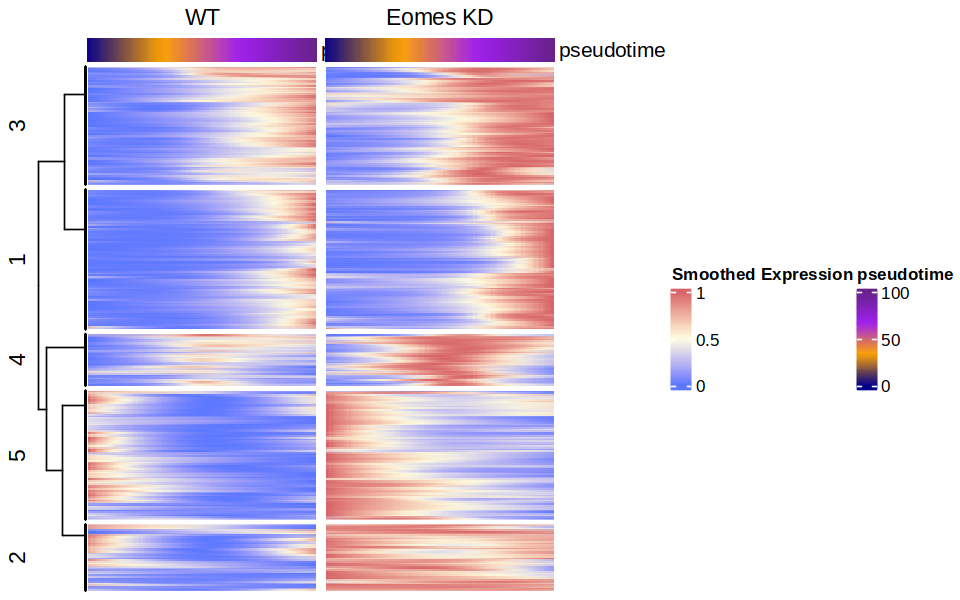

In [221]:
# Clustering
set.seed(42)
k = 5
group = kmeans(yhatSmooth_minmax, centers = k)$cluster
row_clust = cluster_within_group(t(yhatSmooth_minmax), group)

ra = rowAnnotation(foo = anno_mark(at = match(genes_label, rownames(WT)), labels = genes_label))


hm_list = Heatmap(WT, 
                  cluster_rows = row_clust,
                  cluster_columns = FALSE,
                  column_title = 'WT',
                  show_column_names  = FALSE,
                  row_split = k,
                  #row_split = as.data.frame(group), 
                  #km = 6,
                  col = cols,
                  heatmap_legend_param = list(title = 'Smoothed Expression'), 
                  top_annotation = ha) + 
          Heatmap(KO, 
                  cluster_columns = FALSE, 
                  column_title = 'Eomes KD',
                  show_column_names  = FALSE,
                  show_row_names  = FALSE,
                  col = cols,
                  show_heatmap_legend = F, 
                  top_annotation = ha,
                  right_annotation = ra)

options(repr.plot.height=5, repr.plot.width=8)
draw(hm_list)

In [222]:
# matches <- getMatches(ArchRProject, 'Motif_cisbp')
# rownames(matches) = rownames(atac.sce)

io$multiome = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/multiome_atlas/'
silico_chip = readRDS(file.path(io$multiome, 'vitro_peaks_silicoChIP_cisbp.rds'))
assay(silico_chip, 'matches') = assay(silico_chip, 'VirtualChipScores') > 0.2 # keep only motifs with in silico score > 0.2
assay(silico_chip, 'motifScores') = NULL
assay(silico_chip, 'motifMatches') = NULL
assay(silico_chip, 'motifCounts') = NULL
assay(silico_chip, 'VirtualChipScores') = NULL
matches = silico_chip


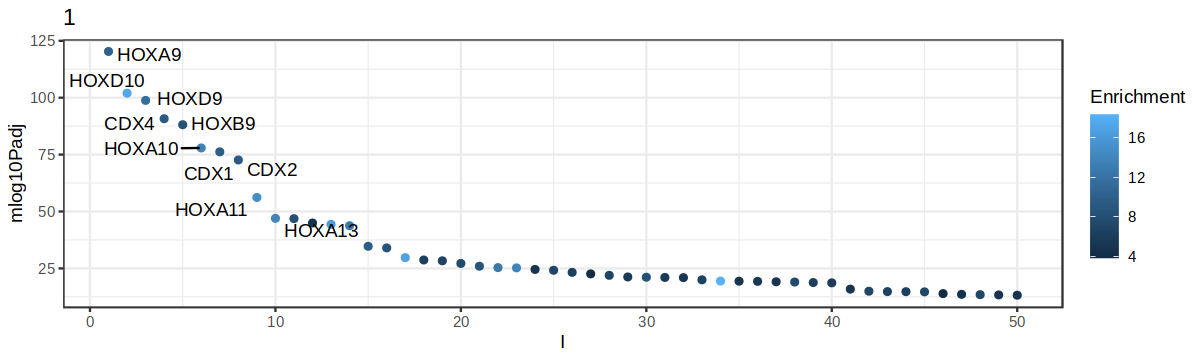

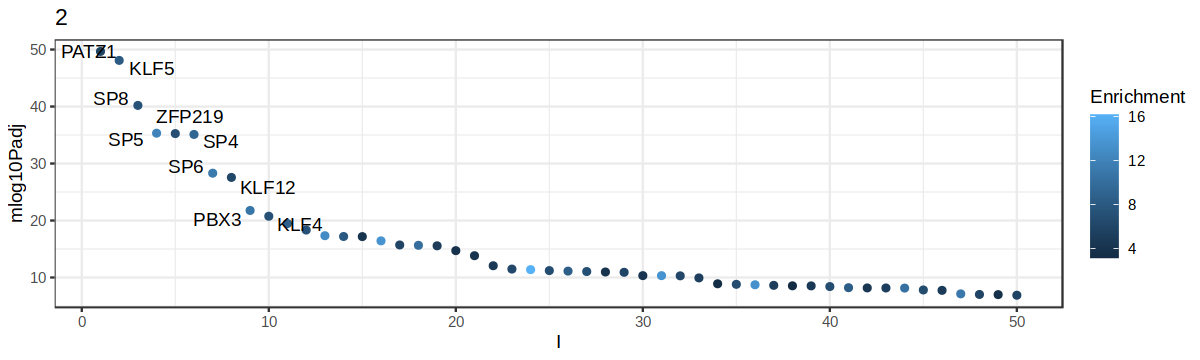

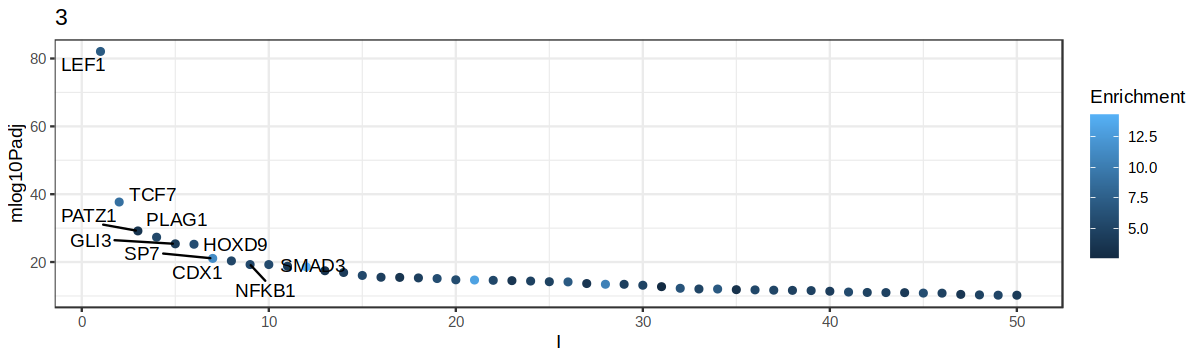

[[1]]

[[2]]

[[3]]

[[4]]

[[5]]


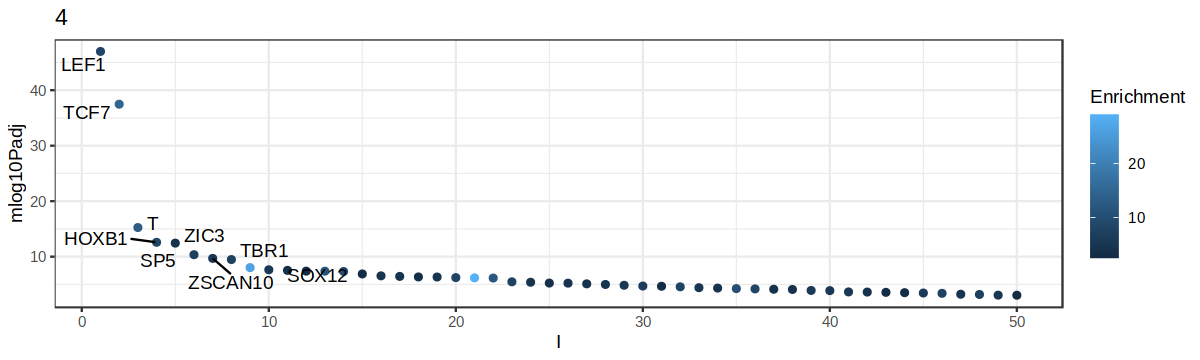

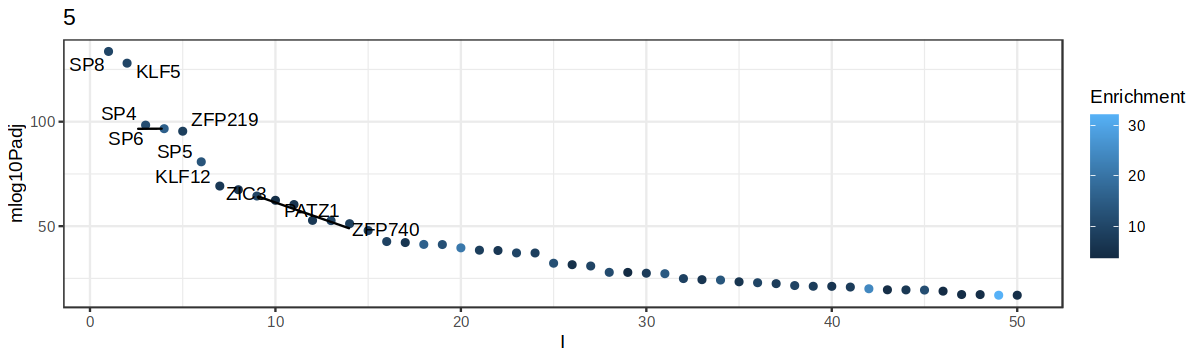

In [223]:
options(repr.plot.width = 10, repr.plot.height = 3)

lapply(1:5, function(x){
    genes = names(group)[group == x]
    tmp2 = as.data.table(ArchR:::.computeEnrichment(matches, genes, seq_len(nrow(matches)))) %>%
            .[,feature := str_split(feature, '_') %>% map_chr(1)] %>% 
            .[mlog10Padj > -log10(0.05)]

    to.plot = tmp2[order(-mlog10Padj)] %>% .[,I := .I]
    ggplot(head(to.plot, 50), aes(I, mlog10Padj, color = Enrichment)) + 
        geom_point() + 
        ggrepel::geom_text_repel(data = head(to.plot,10), aes(label = feature), color = 'black') + 
        ggtitle(x) + 
        theme_bw()
})


In [247]:
args$vitro_bws = file.path(io$basedir, 'processed/atac/archR/GroupBigWigs/celltypeV2_genotype/')

bigwigs.data_vitro = data.table(celltype = list.files(args$vitro_bws, 'bw') %>% str_split(., '\\.') %>% map_chr(1),
                    genotype = list.files(args$vitro_bws, 'bw') %>% str_split(., '\\.') %>% map_chr(2) %>% str_split('-') %>% map_chr(1),
                    path =  paste0(args$vitro_bws, list.files(args$vitro_bws, 'bw'))) %>% 
                .[,name := gsub('KO', 'KD', paste0(celltype, ' ', genotype))] %>% 
                .[,color := ifelse(genotype == 'KO', '#FF0000', '#000000')]

In [280]:
WT_plot$name

[1] Eomes ChIP             T ChIP                 Primitive_Streak KD   
 [4] Primitive_Streak WT    Early_Mes_EOi KD       Early_Mes_EOi WT      
 [7] Posterior_Mes KD       Posterior_Mes WT       Allantois_Precursor KD
[10] Allantois_Precursor WT
10 Levels: Allantois_Precursor KD Allantois_Precursor WT ... T ChIP

In [304]:
chips = data.table(
    celltype = 'ChIP',
    genotype = '',
    path = c('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_bamCoverage_ChIP_EoGFP_dox.bigwig',
            '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_bamCoverage_ChIP_BraGFP_dox.bigwig'),
    name = c('.       Eomes ChIP', '.        T ChIP'),
    color = c('darkgreen', 'darkblue')
)

In [305]:
chips

celltype,genotype,path,name,color
<chr>,<chr>,<chr>,<chr>,<chr>
ChIP,,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_bamCoverage_ChIP_EoGFP_dox.bigwig,. Eomes ChIP,darkgreen
ChIP,,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_bamCoverage_ChIP_BraGFP_dox.bigwig,. T ChIP,darkblue


In [306]:
bigwigs.data = rbind(bigwigs.data_vitro, chips)

In [307]:
unique(bigwigs.data$celltype)

[1] "Allantois_Precursor" "Allantois"           "Blood_Progenitor"   
 [4] "Early_Mes_EOd"       "Early_Mes_EOi"       "Endothelium"        
 [7] "HE_Precursor"        "HE"                  "Mesenchyme"         
[10] "PGC"                 "Posterior_Mes"       "Primitive_Streak"   
[13] "ChIP"

In [308]:
celltypes = c('ChIP', 'Primitive_Streak', 'Early_Mes_EOi', 'Posterior_Mes', 'Allantois_Precursor')

WT_plot = bigwigs.data %>% copy() %>%
    .[celltype %in% celltypes] %>%
    .[, celltype := factor(celltype, levels = celltypes)] %>%
    .[order(celltype)] %>% 
    .[, name := as.factor(name)]

In [310]:
head(WT_plot)

celltype,genotype,path,name,color
<fct>,<chr>,<chr>,<fct>,<chr>
ChIP,,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_bamCoverage_ChIP_EoGFP_dox.bigwig,. Eomes ChIP,darkgreen
ChIP,,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_bamCoverage_ChIP_BraGFP_dox.bigwig,. T ChIP,darkblue
Primitive_Streak,KO,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/GroupBigWigs/celltypeV2_genotype/Primitive_Streak.KO-TileSize-100-normMethod-ReadsInTSS-ArchR.bw,Primitive_Streak KD,#FF0000
Primitive_Streak,WT,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/GroupBigWigs/celltypeV2_genotype/Primitive_Streak.WT-TileSize-100-normMethod-ReadsInTSS-ArchR.bw,Primitive_Streak WT,#000000
Early_Mes_EOi,KO,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/GroupBigWigs/celltypeV2_genotype/Early_Mes_EOi.KO-TileSize-100-normMethod-ReadsInTSS-ArchR.bw,Early_Mes_EOi KD,#FF0000
Early_Mes_EOi,WT,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/GroupBigWigs/celltypeV2_genotype/Early_Mes_EOi.WT-TileSize-100-normMethod-ReadsInTSS-ArchR.bw,Early_Mes_EOi WT,#000000


In [285]:
ArchRProject = loadArchRProject(io$archR.directory)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [257]:
nrow(WT_plot)

[1] 10

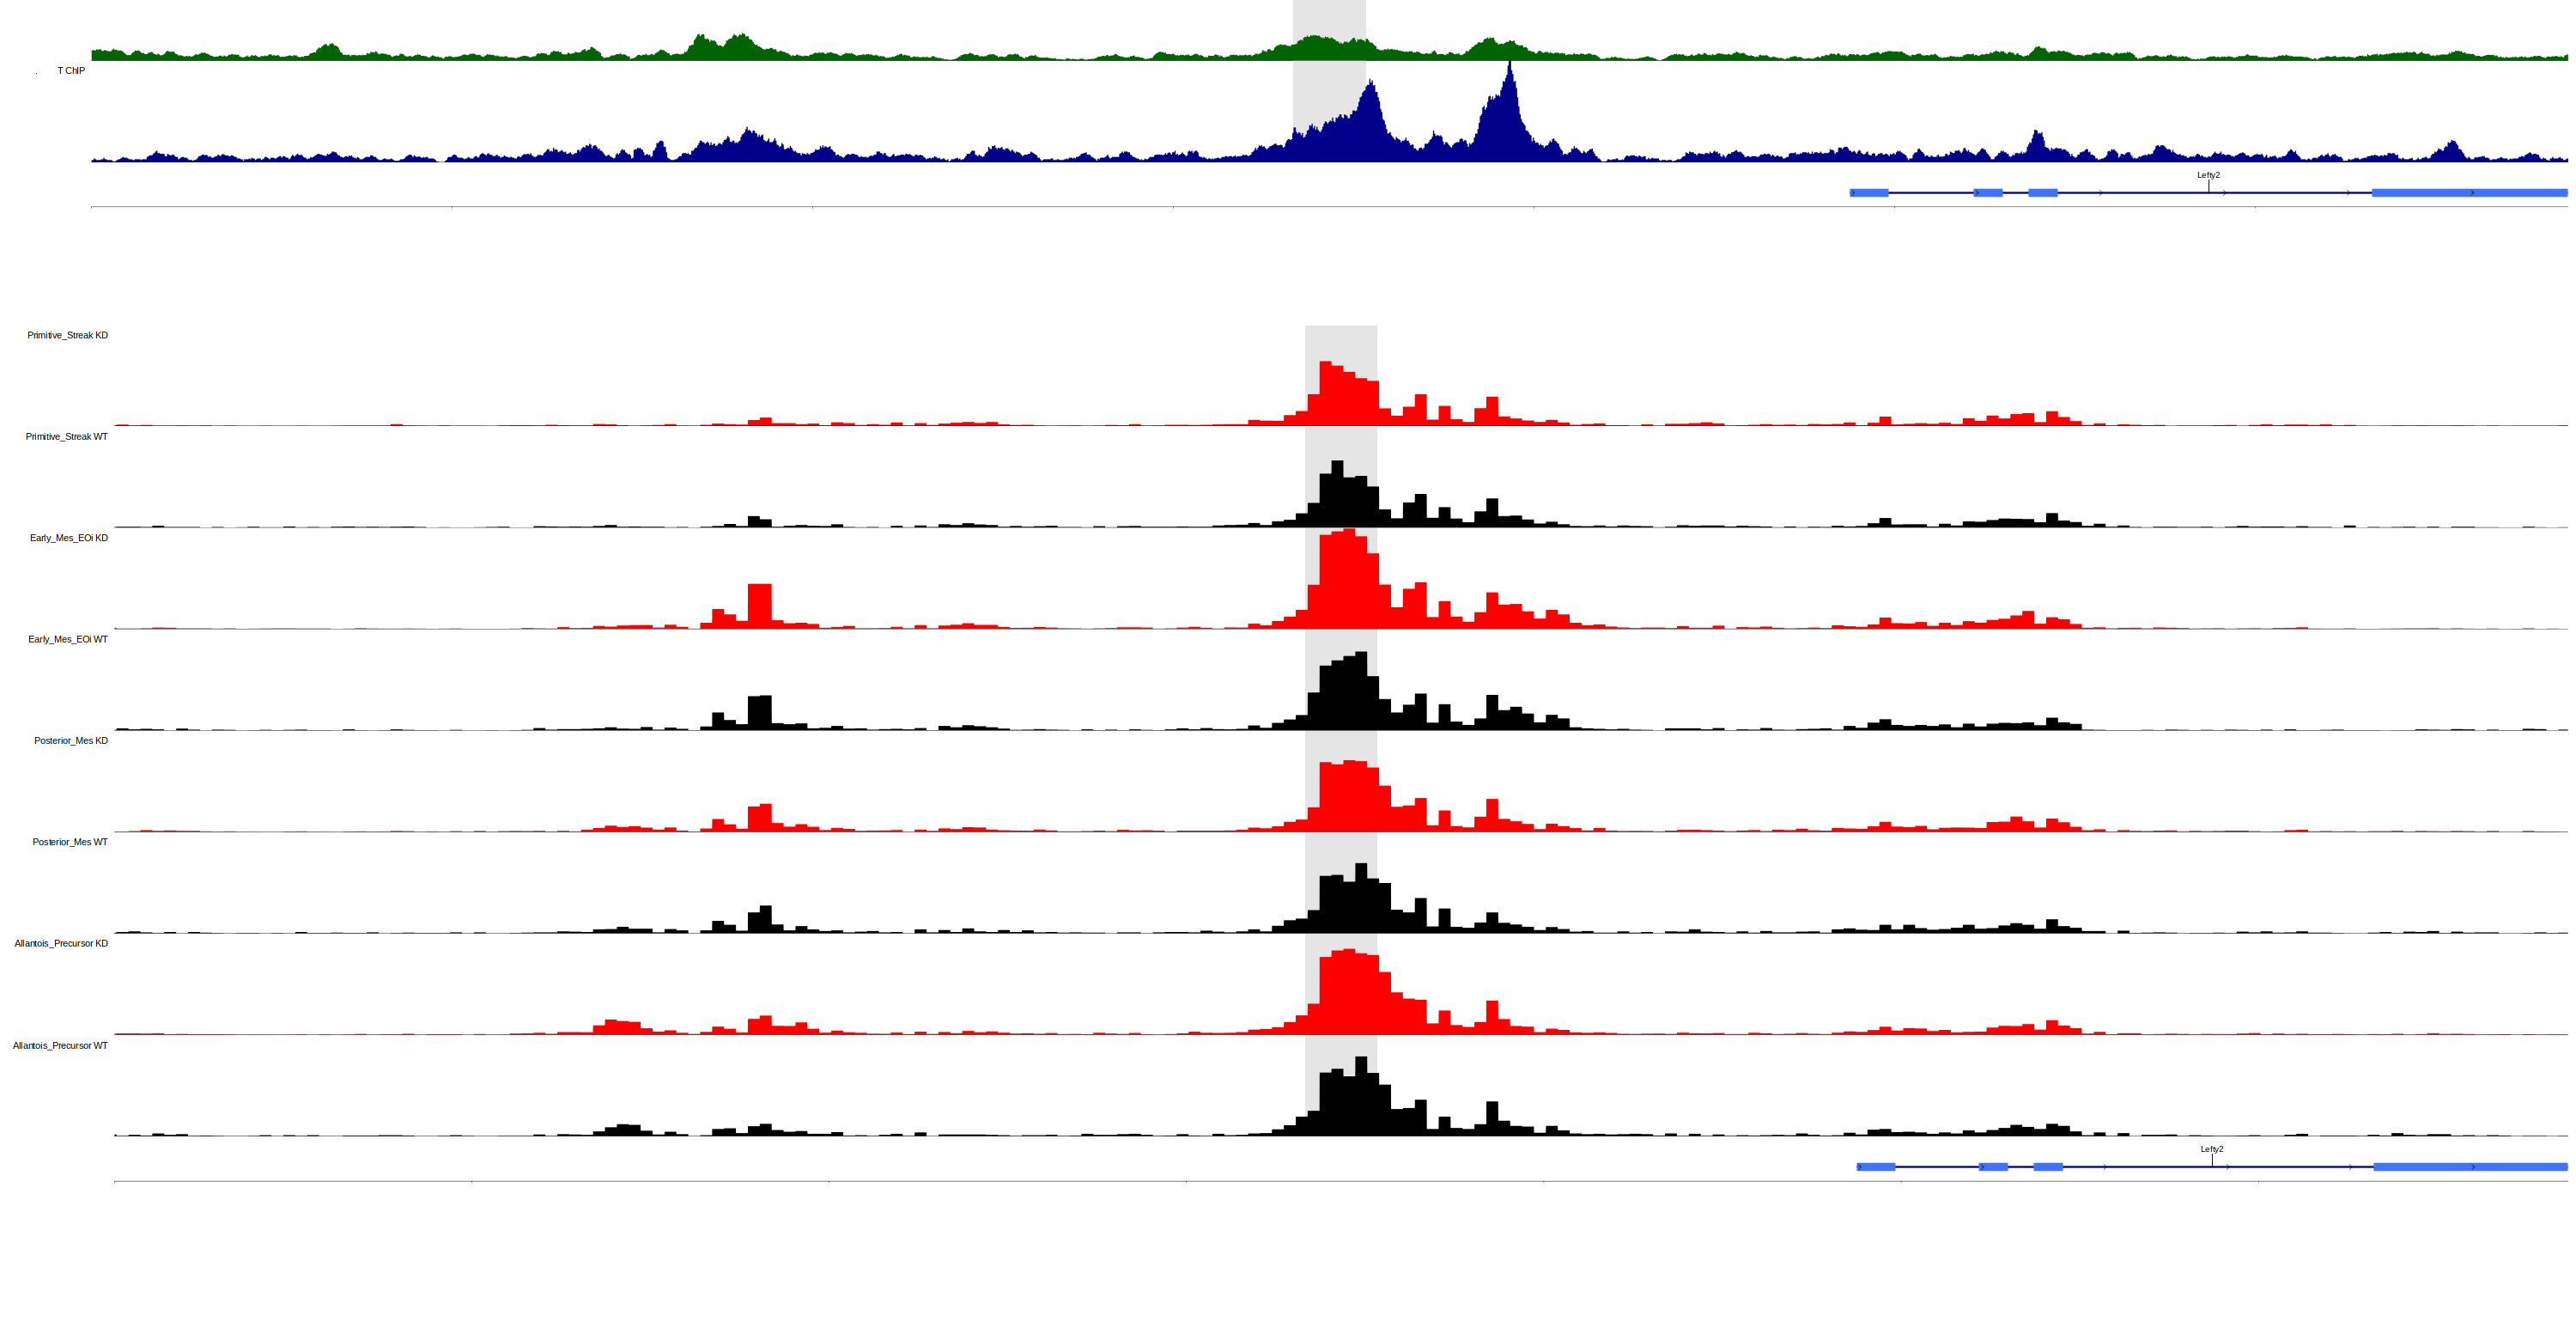

In [315]:
input_region = condRes[1, gene]
extend = 1e4
options(repr.plot.width = 25, repr.plot.height = 13)
ggarrange(plot_browser_track(gene = NULL, # gene used for plotting expression
                              input_region = input_region, # Region used
                              bigwigs = WT_plot[1:2], 
                              extend.upstream = extend,
                              extend.downstream = extend, 
                              highlight_regions = input_region, #if(length(tmp1$peak)>0){tmp1$peak}else{NULL},
                              downsample.rate = 1, 
                              no_label = F, 
                              plot_expression = F,
                              background_color = 'white',
                              highlight_color = 'grey90',
                              bw_height = 25, 
                              gene_height = 10,
                              bw_width = 200,
                              expr_width = 0),

plot_browser_track(gene = NULL, # gene used for plotting expression
                              input_region = input_region, # Region used
                              bigwigs = WT_plot[3:10], 
                              extend.upstream = extend,
                              extend.downstream = extend, 
                              highlight_regions = input_region, #if(length(tmp1$peak)>0){tmp1$peak}else{NULL},
                              downsample.rate = 1, 
                              no_label = F, 
                              plot_expression = F,
                              background_color = 'white',
                              highlight_color = 'grey90',
                              bw_height = 25, 
                              gene_height = 10,
                              bw_width = 200,
                              expr_width = 0),
          ncol = 1, 
          heights = c(1, 7)
)

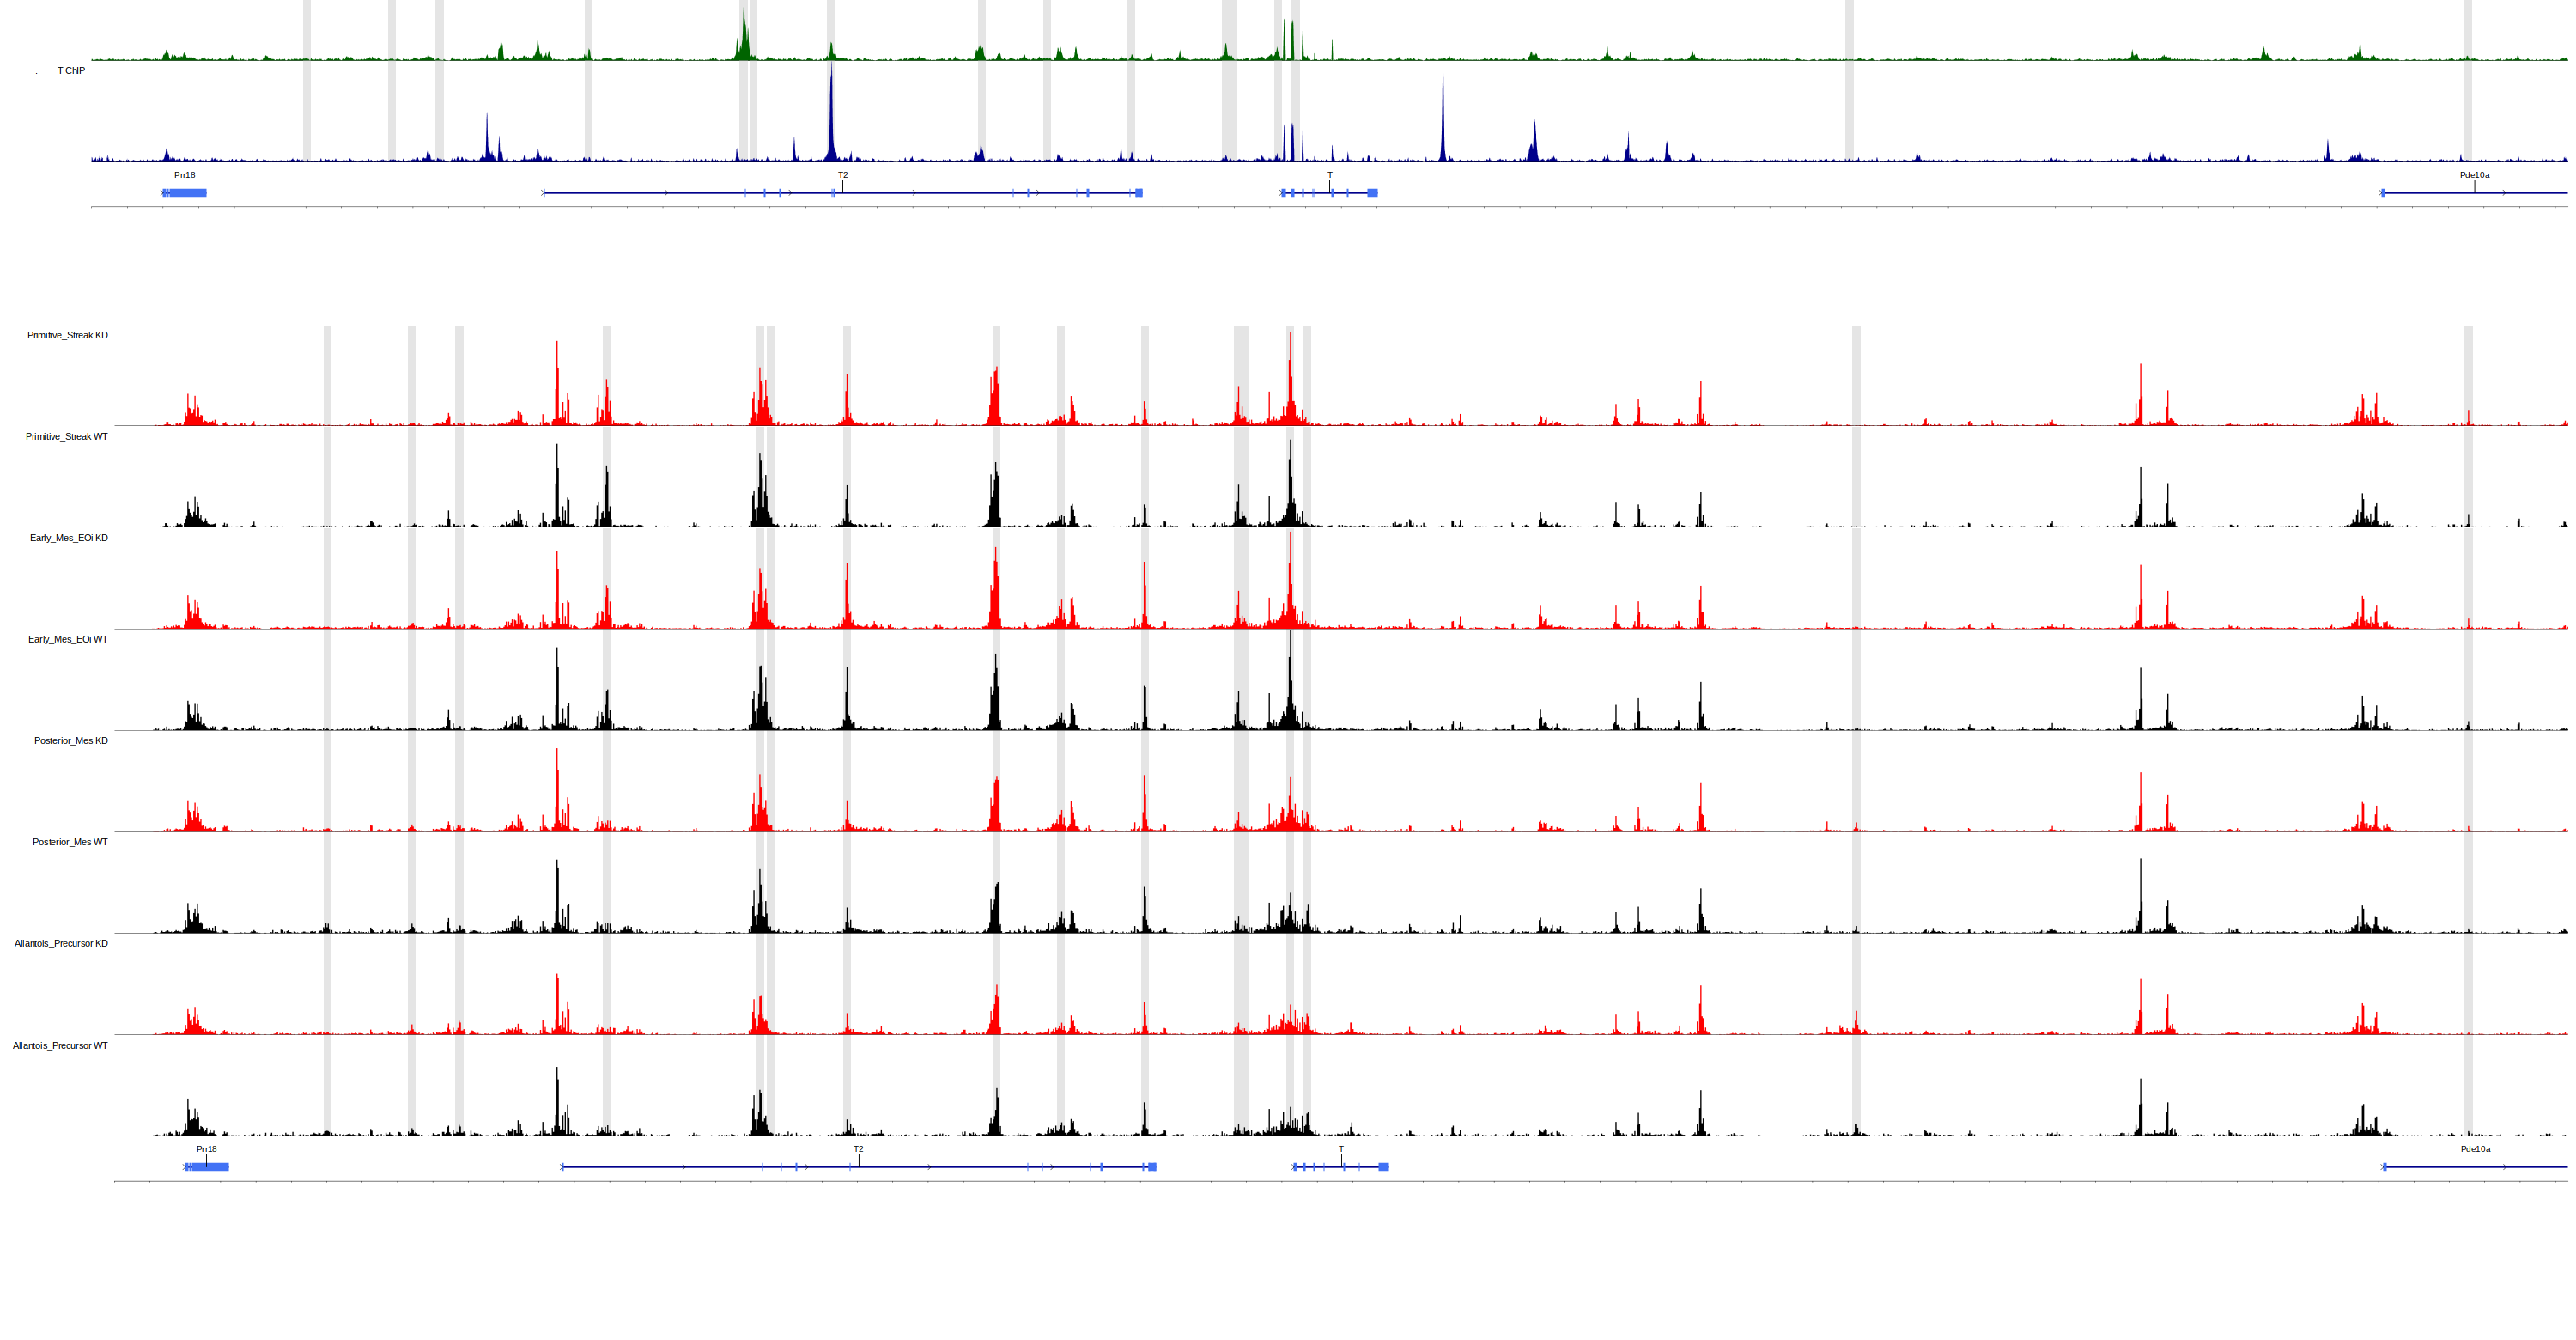

In [320]:
input_region = condRes[sig == T, gene]
extend = 1e5
options(repr.plot.width = 25, repr.plot.height = 13)
ggarrange(plot_browser_track(gene = 'T', # gene used for plotting expression
                              input_region = NULL, # Region used
                              bigwigs = WT_plot[1:2], 
                              extend.upstream = extend,
                              extend.downstream = extend, 
                              highlight_regions = input_region, #if(length(tmp1$peak)>0){tmp1$peak}else{NULL},
                              downsample.rate = 1, 
                              no_label = F, 
                              plot_expression = F,
                              background_color = 'white',
                              highlight_color = 'grey90',
                              bw_height = 25, 
                              gene_height = 10,
                              bw_width = 200,
                              expr_width = 0),

plot_browser_track(gene = 'T', # gene used for plotting expression
                              input_region = NULL, # Region used
                              bigwigs = WT_plot[3:10], 
                              extend.upstream = extend,
                              extend.downstream = extend, 
                              highlight_regions = input_region, #if(length(tmp1$peak)>0){tmp1$peak}else{NULL},
                              downsample.rate = 1, 
                              no_label = F, 
                              plot_expression = F,
                              background_color = 'white',
                              highlight_color = 'grey90',
                              bw_height = 25, 
                              gene_height = 10,
                              bw_width = 200,
                              expr_width = 0),
          ncol = 1, 
          heights = c(1, 7)
)

## ATAC analysis

In [100]:
# atac sce
args$peakmtx = file.path(io$basedir, 'processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds')

In [111]:
######
#### Find variable peaks
######
# load RNA scGAM
sceGAM_RNA = readRDS(file.path(args$outdir, 'sceGAM_v2.rds'))

# load sce atac
atac.sce = readRDS(args$peakmtx)[, colnames(sceGAM_RNA)] # keep only cells from relevant trajectory
colData(atac.sce) = meta2[match(colnames(sceGAM_RNA), cell)] %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()
atac.sce = as(atac.sce, 'SingleCellExperiment')
assayNames(atac.sce) <- "counts"

# load mofa factors
mofa = fread(file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/mofa/MOFA_factors.txt.gz')) %>% 
    .[match(colnames(atac.sce), cell),] %>% 
    as.data.frame() %>% tibble::column_to_rownames('cell') %>% 
    as.matrix

In [112]:
## First cluster cells at high resolution (replicating meta cells)
# Convert to Seurat
suppressPackageStartupMessages(library(Seurat))
seurat = CreateSeuratObject(counts = counts(atac.sce))
seurat[["mofa"]] <- CreateDimReducObject(embeddings = mofa, key = "mofa_", assay = DefaultAssay(seurat))

# First find high resolution clusters across the whole WT dataset
seurat <- FindNeighbors(seurat, reduction  = 'mofa')
seurat <- FindClusters(seurat, resolution = 1.5)
paste0('Number of Clusters: ', length(unique(Idents(seurat))))

# Pseudobulk ATAC by those clusters
atac.pb = aggregateAcrossCells(atac.sce, id=Idents(seurat), statistics="sum", use.assay.type="counts",  BPPARAM = BPPARAM)

# Normalise
assay(atac.pb,"logcounts") <- log(1e6*(sweep(assay(atac.pb),2,colSums(assay(atac.pb),na.rm=T),"/"))+1)

# Get HVGs
decomp <- modelGeneVar(atac.pb, BPPARAM = MulticoreParam(16)) # [expression$gene,]
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% 
    as.data.table(., keep.rownames=T) 

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 7652
Number of edges: 236008

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7135
Number of communities: 15
Elapsed time: 0 seconds


Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via the L'Ecuyer-CMRG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”


[1] "Number of Clusters: 15"

  |======================================================================| 100%



Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


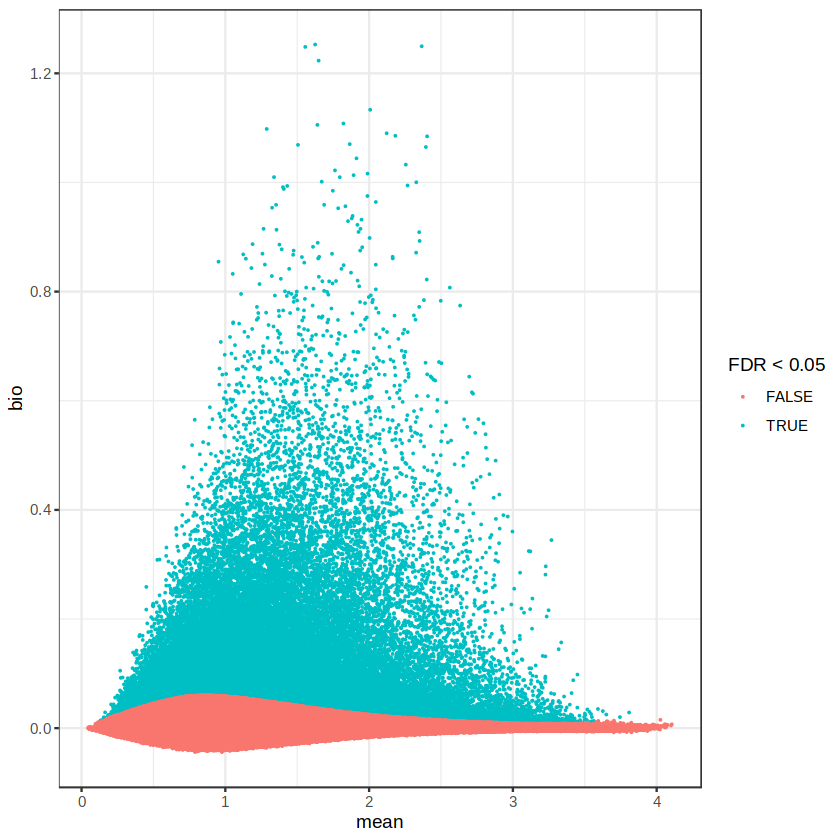

In [113]:
ggplot(hvgs, aes(mean, bio, color = FDR < 0.05)) + 
    geom_point(size = 0.02) + 
    theme_bw()

In [114]:
nrow(hvgs[FDR< 0.05])

[1] 43255

In [115]:
summary(colnames(atac.sce) == colnames(sceGAM))
summary(hvgs$rn %in% rownames(atac.sce))

   Mode    TRUE 
logical    7652 

   Mode    TRUE 
logical  234908 

In [116]:
# Get pseudotime and weights from RNA sceGAM (To make sure the exact same weights are used between modalities)
pseudotime = as.data.frame(sceGAM$crv[,c(1)])
weight = as.data.frame(sceGAM$crv[,c(2)])

# Export files to run as Rscript
R_script_list = list(cells = colnames(atac.sce),
                     peaks = rownames(atac.sce),
                     peak_stats = hvgs,
                     genotype = atac.sce$genotype,
                     replicate = atac.sce$replicate,
                     pseudotime = pseudotime,
                     weight = weight)

saveRDS(R_script_list, file.path(args$outdir, 'ATAC_tradeseq_objects_v2.rds'))

In [ ]:
# # #Following code ran as Rscript: 09_Eomes_invitro_blood/code/rna_atac/revisions/01_tradeSeq_ATAC_all_peaks.R
# here::i_am("revisions/04_TEomes_interaction/01_AllantoisTrajectory_KDvWT.ipynb")

# source(here::here("settings.R"))
# source(here::here("utils.R"))

# suppressPackageStartupMessages(library(scran))
# suppressPackageStartupMessages(library(scater))
# suppressPackageStartupMessages(library(Seurat))
# suppressPackageStartupMessages(library(dplyr))
# suppressPackageStartupMessages(library(edgeR))
# suppressPackageStartupMessages(library(destiny))
# suppressPackageStartupMessages(library(tradeSeq))
# suppressPackageStartupMessages(library(slingshot))
# suppressPackageStartupMessages(library(BiocParallel))

# BPPARAM <- BiocParallel::bpparam()
# BPPARAM$workers = 24

# # Multi core using future - built in to seurat
# plan("multicore", workers = 16)
# options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM
# set.seed(6)

# # I/O
# args = list()

# # atac sce
# args$peakmtx = file.path(io$basedir, 'processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds')

# # outdir
# args$outdir = file.path(io$basedir, 'results/revisions/04_TEomes_interaction/')
# dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

# print('Loading objects')
# R_script_list = readRDS(file.path(args$outdir, 'ATAC_tradeseq_objects_v2.rds'))

# print('loading peak mtx')
# peaks.sce = readRDS(args$peakmtx)[,R_script_list$cells]

# peaks.mtx = peaks.sce@assays@data$PeakMatrix
# rownames(peaks.mtx) = R_script_list$peaks
# colnames(peaks.mtx) = R_script_list$cells

# # Get model matrix
# U <- model.matrix(~R_script_list$replicate)

# print('Running fitGAM')
# sceGAM <- fitGAM(counts = peaks.mtx,
#               #   sds = rna.sce$slingshot,
#                  pseudotime = R_script_list$pseudotime,
#                  conditions = factor(R_script_list$genotype, levels = c('KO', 'WT')), # KD vs WT comparison
#                  cellWeights = R_script_list$weight, # All cells belong to the same trajectory                 
#                  U = U,
#                  nknots=8, 
#             #     genes = unique(R_script_list$peak_gene_correlation[padj<0.05][,1][[1]]), # Keep only peaks that are linked to the differential genes
#                  genes = R_script_list$peak_stats[FDR<0.05, rn],
#                  parallel = TRUE,
#                  BPPARAM=BPPARAM,
#                  verbose=T) 

# saveRDS(sceGAM, file.path(args$outdir, 'sceGAM_ATAC_all_peaks_v2.rds'))

[1] "Loading objects"
[1] "loading peak mtx"
[1] "Running fitGAM"


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 13.4 GiB”


  |==                                                                    |   3%

In [3]:
sceGAM = readRDS(file.path(args$outdir, 'sceGAM_ATAC_all_peaks_v2.rds'))

In [4]:
sceGAM

class: SingleCellExperiment 
dim: 43255 7652 
metadata(1): tradeSeq
assays(1): counts
rownames(43255): chr1:7020455-7021055 chr1:7671642-7672242 ...
  chr7:84247839-84248439 chr8:77544337-77544937
rowData names(1): tradeSeq
colnames(7652): 2_Eo_DEG_G9_day3_5_VC#AAACATGCAAGCGATG-1
  2_Eo_DEG_G9_day3_5_VC#AAACCAACACCCACAG-1 ...
  rv_eo_deg_day4_dtag#TTTGTCTAGTTAGTGC-1
  rv_eo_deg_day4_dtag#TTTGTGGCACAAAGAC-1
colData names(2): crv tradeSeq
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [5]:
# Test if l2fc should be changed around? 
condRes <- conditionTest(sceGAM, l2fc = 0)
condRes$padj <- p.adjust(condRes$pvalue, "fdr")

In [6]:
condRes = condRes %>% as.data.table(keep.rownames=T) %>%
    setnames('rn', 'gene') %>%
    .[,sig:=ifelse(padj<=0.05, TRUE, FALSE)] %>%
    .[order(padj, -waldStat)]

In [7]:
fwrite(condRes, file.path(args$outdir, 'condRes_ATAC_v2.txt.gz'))

In [5]:
condRes = fread(file.path(args$outdir, 'condRes_ATAC_v2.txt.gz'))

In [6]:
nrow(condRes[sig == T])

[1] 7040

In [7]:
yhatSmooth <- as.data.table(predictSmooth(sceGAM, gene = condRes[sig == T, gene], nPoints = 100, tidy=TRUE))

In [17]:
genes_keep = condRes[sig==T, gene]
genes_label = NULL #condRes[sig==T, gene]

trans <- div_gradient_pal(low='#ba4a04', mid='lightyellow', high='#1a7800')

cols <- trans(seq(0,1, length.out=20))
# col_fun = colorRamp2(seq(0, 100, 5), viridis::viridis(length(seq(0, 100, 5))))
col_fun = colorRamp2(seq(0, 100, 5), colorRampPalette(c("darkblue", "orange", "purple", 'darkorchid4'))(length(seq(0, 100, 5))))

## Create a top annotation for the clusters
palette2 <- colorRampPalette(c("darkblue", "orange", "orchid1", 'darkorchid4'))  # Alnt trajectory palette

# Allantois heatmap annotation
pseudo_min = 2
pseudo_max = 10
ii <- cut(seq(pseudo_min, pseudo_max, len = 100), breaks = seq(0, max(meta2[trajectory == 'Traj2', pseudotime]), len = 100), 
          include.lowest = TRUE)
colors <- palette2(99)[ii]
ha_alnt <- HeatmapAnnotation(
                          pseudotime = 1:100,
                          col = list(pseudotime = colorRamp2(1:100, colors)),
                          show_legend = FALSE,
                          show_annotation_name = FALSE,
                          simple_anno_size   = unit(2, "mm")  # Adjust the height as needed, for example unit(2, "cm")
)

yhatSmooth <- predictSmooth(sceGAM, gene = genes_keep, nPoints = 100, tidy = FALSE)

# minmax normalisation 
minmax = function(x){(x-min(x))/(max(x)-min(x))}
yhatSmooth_minmax = t(apply(yhatSmooth, 1, minmax)) 

WT = yhatSmooth_minmax[, grepl('lineage1_conditionWT', colnames(yhatSmooth_minmax))]
KO = yhatSmooth_minmax[, grepl('lineage1_conditionKO', colnames(yhatSmooth_minmax))]

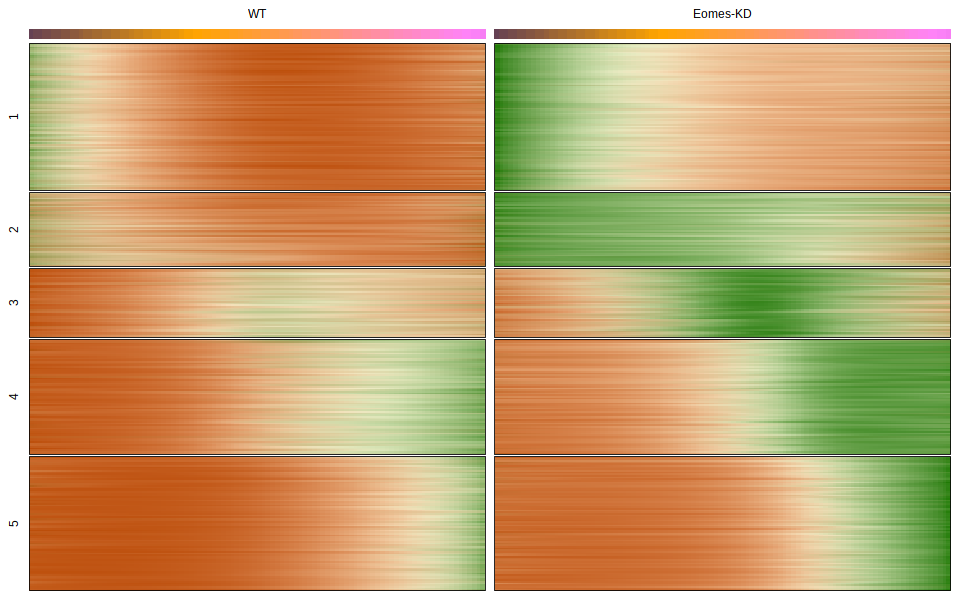

In [18]:

set.seed(42)
k = 5
group = kmeans(yhatSmooth_minmax, centers = k)$cluster

group_rename = c(
    '3' = '1',
    '2' = '2', 
    '5' = '3', 
    '4' = '4',                
    '1' = '5'
)

tmp = group
group = as.integer(group_rename[match(group, names(group_rename))])
names(group) = names(tmp)
#row_clust = cluster_within_group(t(yhatSmooth_minmax), group)

hm_list = Heatmap(WT, 
           row_gap = unit(0.5, "mm"),
            cluster_columns = FALSE,
            column_title = 'WT',
            show_column_names  = FALSE,
            show_row_names  = FALSE,
            col = cols,
            show_heatmap_legend = FALSE,
            row_split = group, 
           # left_annotation = ha_row,
            show_row_dend = FALSE,
            row_order = order(group, decreasing = TRUE),
            # heatmap_legend_param = list(title = 'Expression'), 
            row_title_gp = gpar(fontsize = 7),
            column_title_gp = gpar(fontsize = 7),
            top_annotation = ha_alnt,
            border = TRUE,
            border_gp = gpar(col = "black", lwd = 0.5),
            use_raster = TRUE,
            raster_device = "png",
            raster_quality = 1) + 
          Heatmap(KO, 
           row_gap = unit(0.5, "mm"),
            cluster_columns = FALSE,
            column_title = 'Eomes-KD',
            show_column_names  = FALSE,
            show_row_names  = FALSE,
            col = cols,
            show_heatmap_legend = FALSE,
            row_split = group, 
           # left_annotation = ha_row,
            show_row_dend = FALSE,
            row_order = order(group, decreasing = TRUE),
            # heatmap_legend_param = list(title = 'Expression'), 
            row_title_gp = gpar(fontsize = 7),
            column_title_gp = gpar(fontsize = 7),
            top_annotation = ha_alnt,
            border = TRUE,
            border_gp = gpar(col = "black", lwd = 0.5),
            use_raster = TRUE,
            raster_device = "png",
            raster_quality = 1)

options(repr.plot.height=5, repr.plot.width=8)
draw(hm_list)

In [23]:
fwrite(as.data.table(WT, keep.rownames = T) %>% setnames('rn', 'peak'), file.path(args$outdir, 'Allantois_ATAC_WT.txt.gz'))
fwrite(as.data.table(KO, keep.rownames = T) %>% setnames('rn', 'peak'), file.path(args$outdir, 'Allantois_ATAC_KD.txt.gz'))

In [268]:
pdf(file = file.path(args$outdir, 'trajectory_ATAC_heatmap.pdf'), 
   width = 1.85, 
   height = 2.5)
    draw(hm_list)
dev.off()

png 
  2

In [249]:
group.dt = as.data.table(group, keep.rownames = T) %>% setnames('rn', 'region')
fwrite(group.dt, file.path(args$outdir, 'atac_groups.txt.gz'))

In [250]:
# matches <- getMatches(ArchRProject, 'Motif_cisbp')
# rownames(matches) = rownames(atac.sce)

io$multiome = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/multiome_atlas/'
silico_chip = readRDS(file.path(io$multiome, 'vitro_peaks_silicoChIP_cisbp.rds'))
assay(silico_chip, 'matches') = assay(silico_chip, 'VirtualChipScores') > 0.2 # keep only motifs with in silico score > 0.2
assay(silico_chip, 'motifScores') = NULL
assay(silico_chip, 'motifMatches') = NULL
assay(silico_chip, 'motifCounts') = NULL
assay(silico_chip, 'VirtualChipScores') = NULL
matches = silico_chip


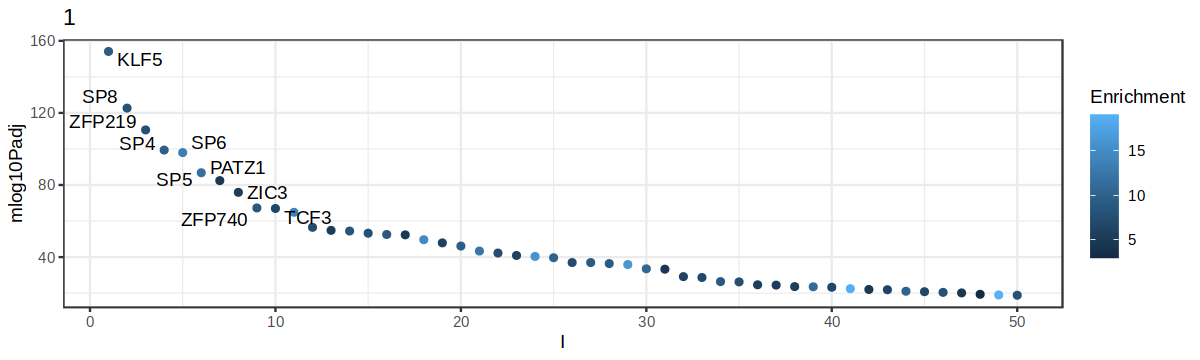

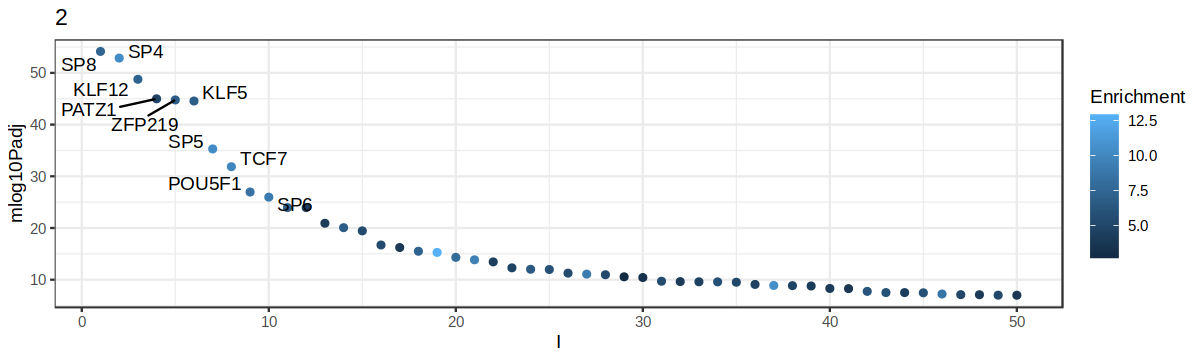

Warning message:
“ggrepel: 4 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


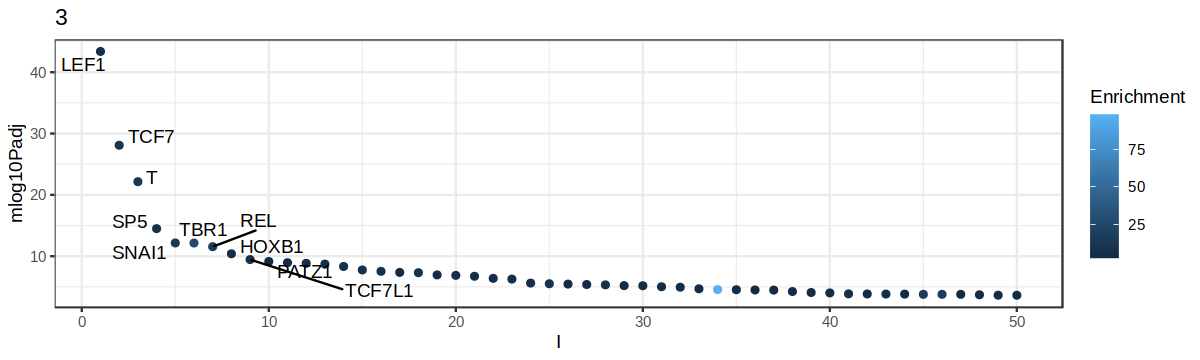

[[1]]

[[2]]

[[3]]

[[4]]

[[5]]


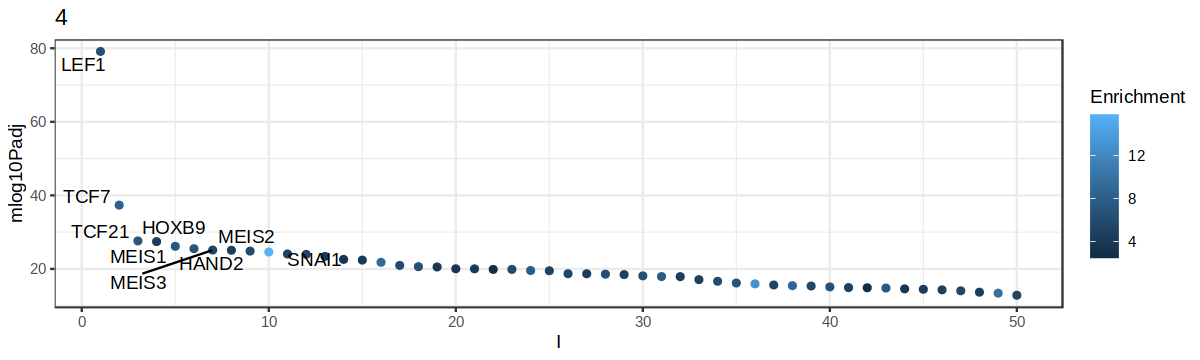

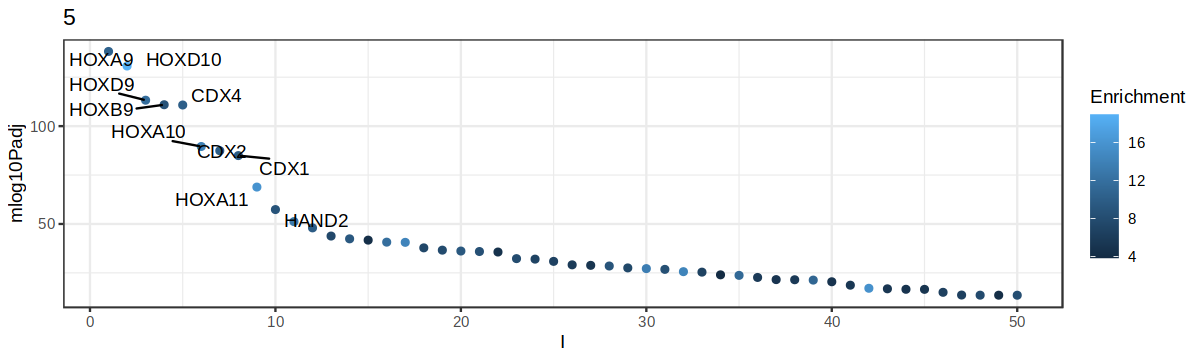

In [251]:
options(repr.plot.width = 10, repr.plot.height = 3)

lapply(1:5, function(x){
    genes = names(group)[group == x]
    tmp2 = as.data.table(ArchR:::.computeEnrichment(matches, genes, seq_len(nrow(matches)))) %>%
            .[,feature := str_split(feature, '_') %>% map_chr(1)] %>% 
            .[mlog10Padj > -log10(0.05)]

    to.plot = tmp2[order(-mlog10Padj)] %>% .[,I := .I]
    ggplot(head(to.plot, 50), aes(I, mlog10Padj, color = Enrichment)) + 
        geom_point() + 
        ggrepel::geom_text_repel(data = head(to.plot,10), aes(label = feature), color = 'black') + 
        ggtitle(x) + 
        theme_bw()
})


### BrowserPlot

In [252]:
args$vitro_bws = file.path(io$basedir, 'processed/atac/archR/GroupBigWigs/celltypeV2_genotype/')

bigwigs.data_vitro = data.table(celltype = list.files(args$vitro_bws, 'bw') %>% str_split(., '\\.') %>% map_chr(1),
                    genotype = list.files(args$vitro_bws, 'bw') %>% str_split(., '\\.') %>% map_chr(2) %>% str_split('-') %>% map_chr(1),
                    path =  paste0(args$vitro_bws, list.files(args$vitro_bws, 'bw'))) %>% 
                .[,name := gsub('KO', 'KD', paste0(celltype, ' ', genotype))] %>% 
                .[,color := ifelse(genotype == 'KO', '#FF0000', '#000000')]

In [332]:
WT_plot$name

[1] .       Eomes ChIP     .        T ChIP        Primitive_Streak KD   
 [4] Primitive_Streak WT    Early_Mes_EOi KD       Early_Mes_EOi WT      
 [7] Posterior_Mes KD       Posterior_Mes WT       Allantois_Precursor KD
[10] Allantois_Precursor WT
10 Levels: .        T ChIP .       Eomes ChIP ... Primitive_Streak WT

In [333]:
chips = data.table(
    celltype = 'ChIP',
    genotype = '',
    path = c('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_bamCoverage_ChIP_EoGFP_dox.bigwig',
            '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_bamCoverage_ChIP_BraGFP_dox.bigwig'),
    name = c('.       Eomes ChIP', '.        T ChIP'),
    color = c('darkgreen', 'darkblue')
)

In [334]:
chips

celltype,genotype,path,name,color
<chr>,<chr>,<chr>,<chr>,<chr>
ChIP,,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_bamCoverage_ChIP_EoGFP_dox.bigwig,. Eomes ChIP,darkgreen
ChIP,,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_bamCoverage_ChIP_BraGFP_dox.bigwig,. T ChIP,darkblue


In [335]:
bigwigs.data = rbind(bigwigs.data_vitro, chips)

In [336]:
unique(bigwigs.data$celltype)

[1] "Allantois_Precursor" "Allantois"           "Blood_Progenitor"   
 [4] "Early_Mes_EOd"       "Early_Mes_EOi"       "Endothelium"        
 [7] "HE_Precursor"        "HE"                  "Mesenchyme"         
[10] "PGC"                 "Posterior_Mes"       "Primitive_Streak"   
[13] "ChIP"

In [337]:
celltypes = c('ChIP', 'Primitive_Streak', 'Early_Mes_EOi', 'Posterior_Mes', 'Allantois_Precursor')

WT_plot = bigwigs.data %>% copy() %>%
    .[celltype %in% celltypes] %>%
    .[, celltype := factor(celltype, levels = celltypes)] %>%
    .[order(celltype)] %>% 
    .[, name := as.factor(name)]

In [338]:
head(WT_plot)

celltype,genotype,path,name,color
<fct>,<chr>,<chr>,<fct>,<chr>
ChIP,,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_bamCoverage_ChIP_EoGFP_dox.bigwig,. Eomes ChIP,darkgreen
ChIP,,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_bamCoverage_ChIP_BraGFP_dox.bigwig,. T ChIP,darkblue
Primitive_Streak,KO,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/GroupBigWigs/celltypeV2_genotype/Primitive_Streak.KO-TileSize-100-normMethod-ReadsInTSS-ArchR.bw,Primitive_Streak KD,#FF0000
Primitive_Streak,WT,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/GroupBigWigs/celltypeV2_genotype/Primitive_Streak.WT-TileSize-100-normMethod-ReadsInTSS-ArchR.bw,Primitive_Streak WT,#000000
Early_Mes_EOi,KO,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/GroupBigWigs/celltypeV2_genotype/Early_Mes_EOi.KO-TileSize-100-normMethod-ReadsInTSS-ArchR.bw,Early_Mes_EOi KD,#FF0000
Early_Mes_EOi,WT,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/GroupBigWigs/celltypeV2_genotype/Early_Mes_EOi.WT-TileSize-100-normMethod-ReadsInTSS-ArchR.bw,Early_Mes_EOi WT,#000000


In [339]:
ArchRProject = loadArchRProject(io$archR.directory)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [340]:
nrow(WT_plot)

[1] 10

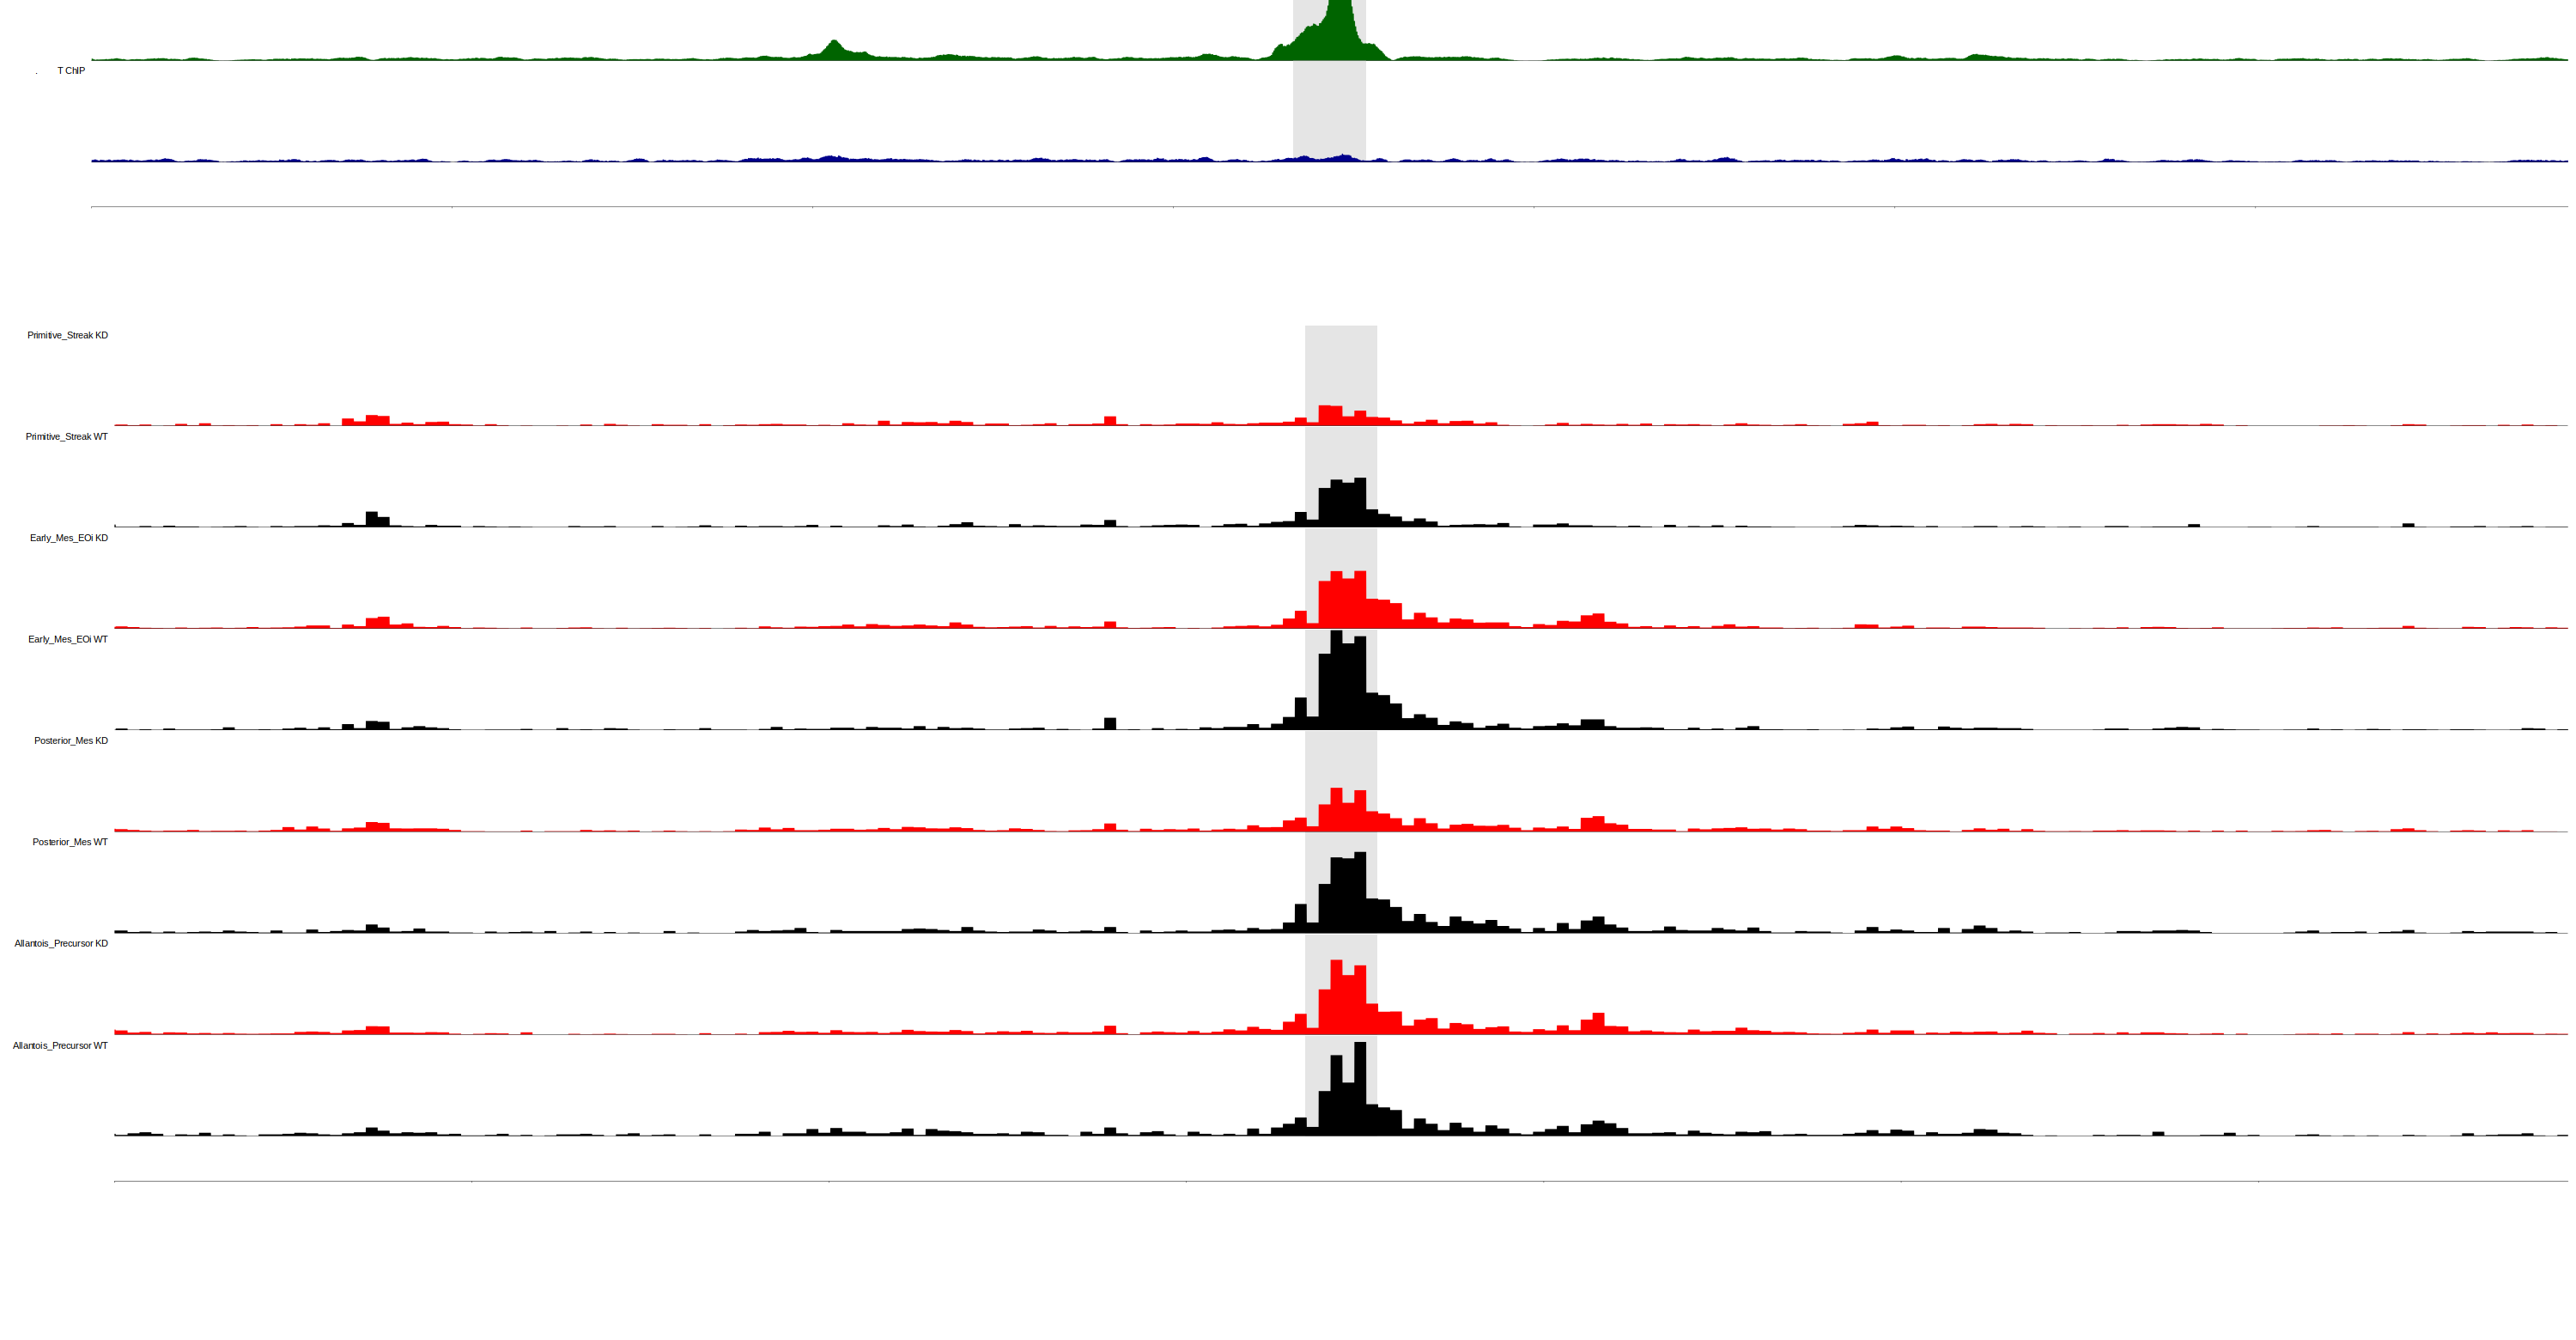

In [341]:
input_region = condRes[1, gene]
extend = 1e4
options(repr.plot.width = 25, repr.plot.height = 13)
ggarrange(plot_browser_track(gene = NULL, # gene used for plotting expression
                              input_region = input_region, # Region used
                              bigwigs = WT_plot[1:2], 
                              extend.upstream = extend,
                              extend.downstream = extend, 
                              highlight_regions = input_region, #if(length(tmp1$peak)>0){tmp1$peak}else{NULL},
                              downsample.rate = 1, 
                              no_label = F, 
                              plot_expression = F,
                              background_color = 'white',
                              highlight_color = 'grey90',
                              bw_height = 25, 
                              gene_height = 10,
                              bw_width = 200,
                              expr_width = 0),

plot_browser_track(gene = NULL, # gene used for plotting expression
                              input_region = input_region, # Region used
                              bigwigs = WT_plot[3:10], 
                              extend.upstream = extend,
                              extend.downstream = extend, 
                              highlight_regions = input_region, #if(length(tmp1$peak)>0){tmp1$peak}else{NULL},
                              downsample.rate = 1, 
                              no_label = F, 
                              plot_expression = F,
                              background_color = 'white',
                              highlight_color = 'grey90',
                              bw_height = 25, 
                              gene_height = 10,
                              bw_width = 200,
                              expr_width = 0),
          ncol = 1, 
          heights = c(1, 7)
)

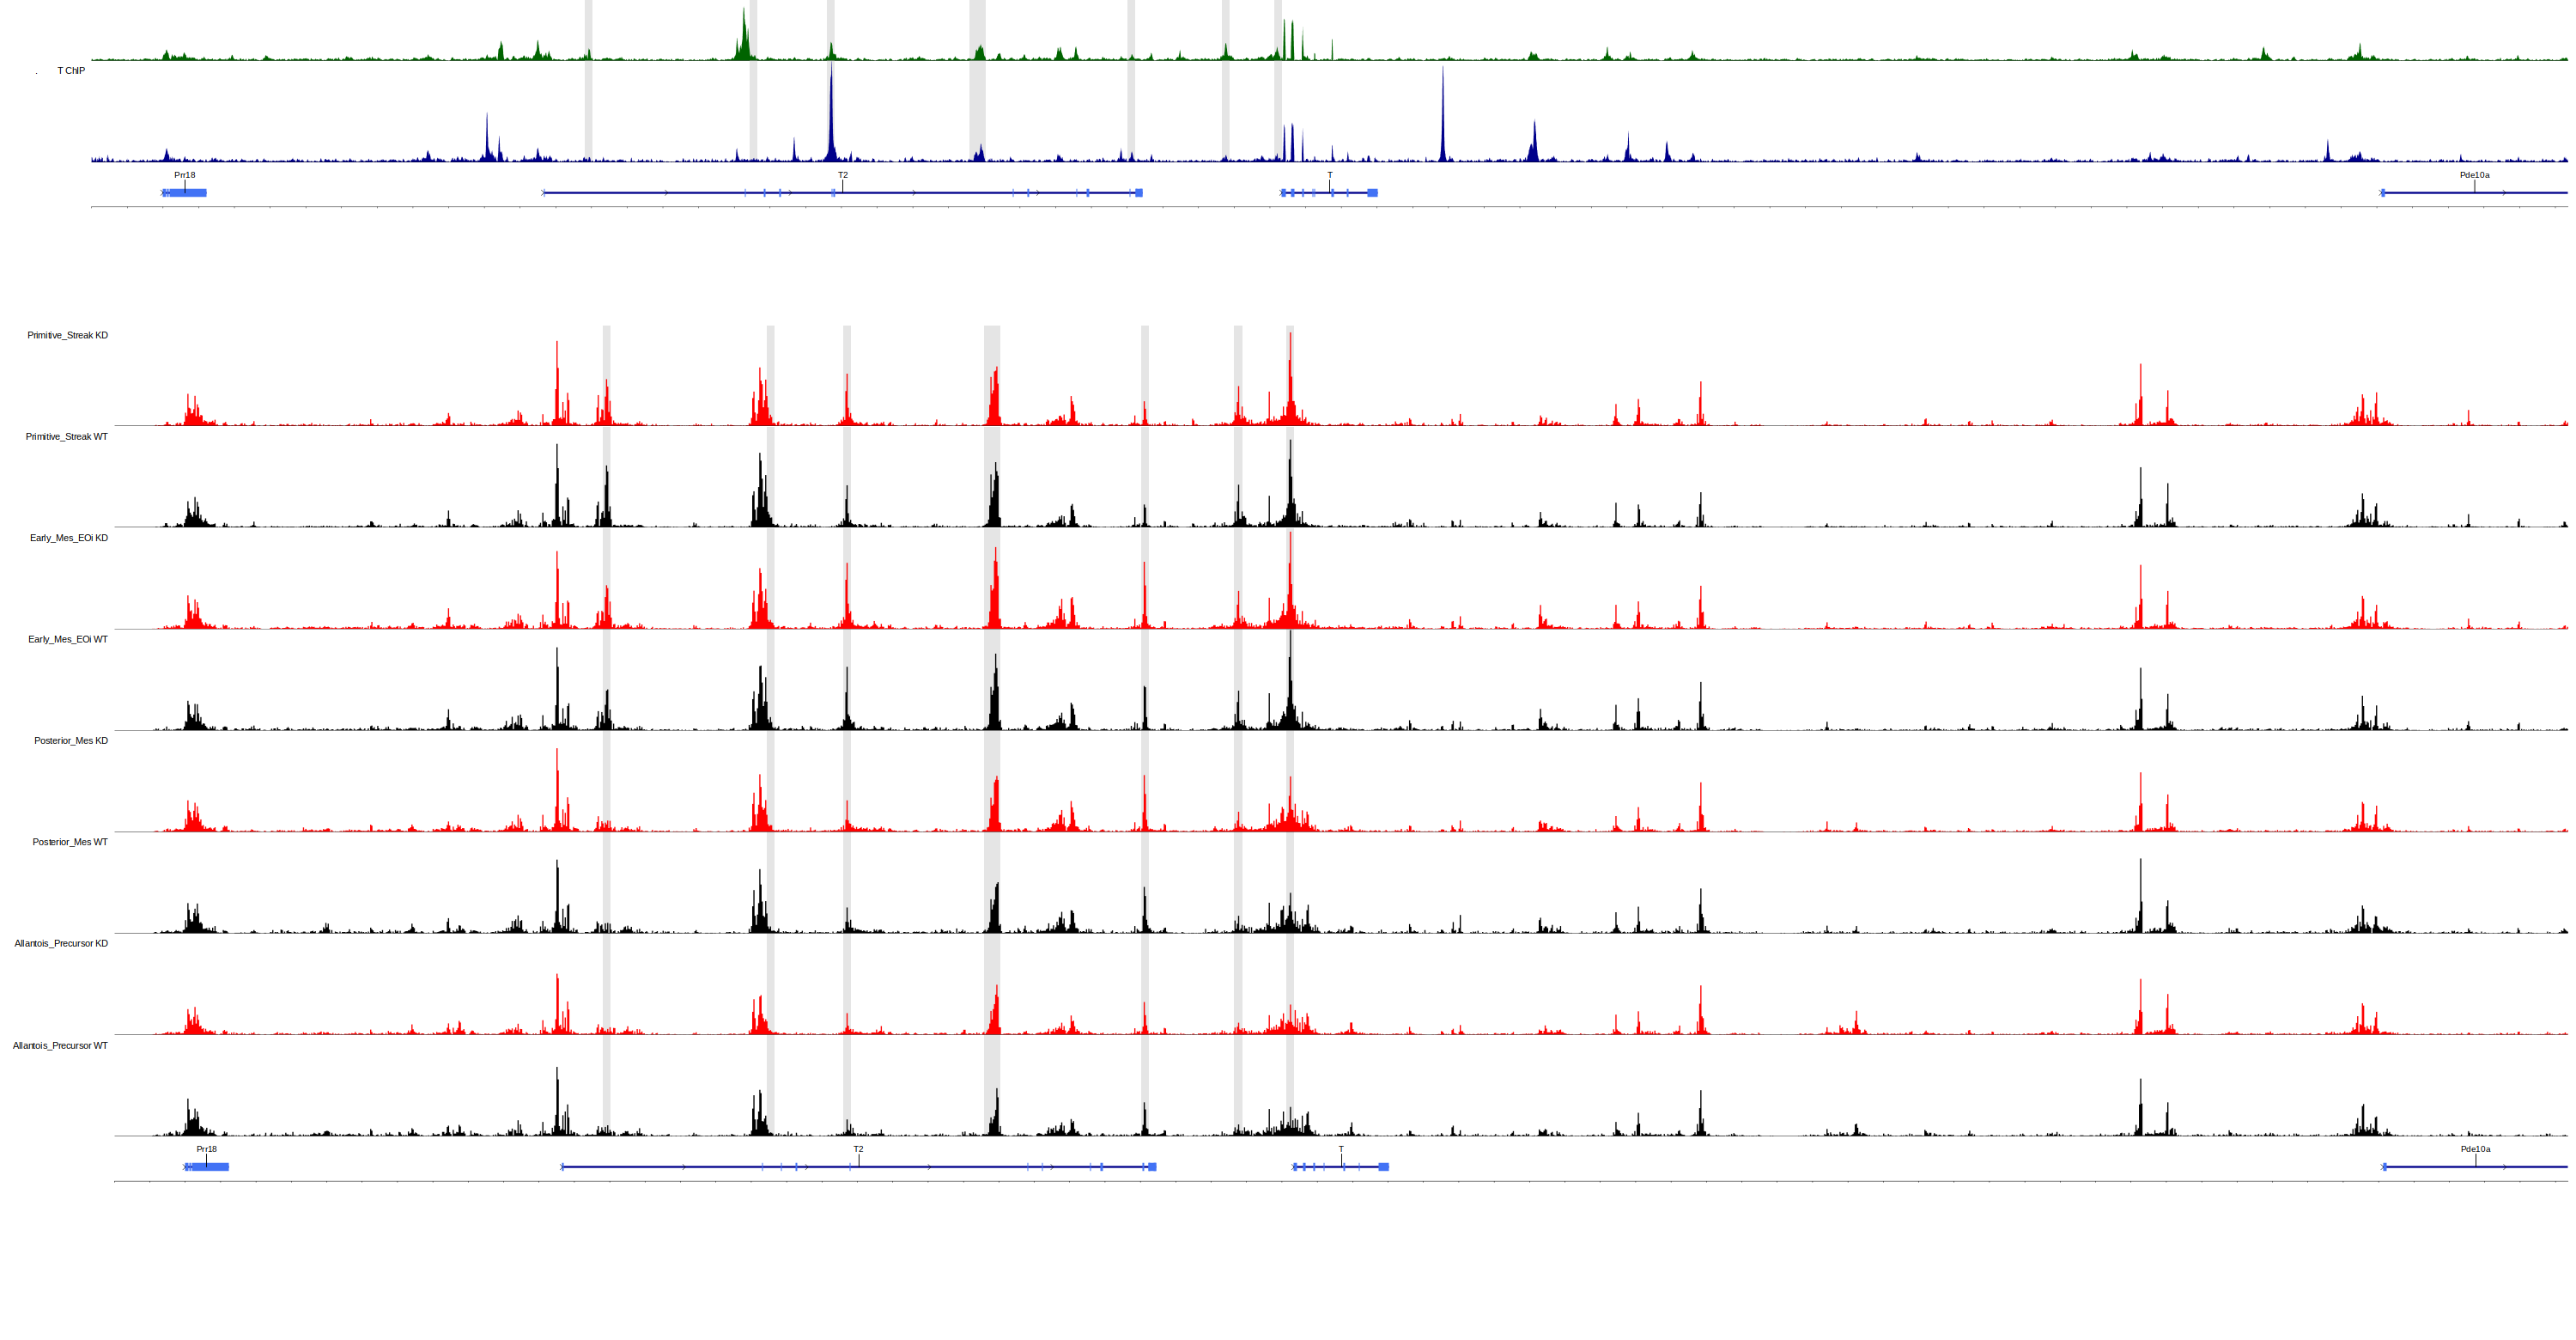

In [347]:
input_region = condRes[sig == T, gene]
extend = 1e5
options(repr.plot.width = 25, repr.plot.height = 13)
ggarrange(plot_browser_track(gene = 'T', # gene used for plotting expression
                              input_region = NULL, # Region used
                              bigwigs = WT_plot[1:2], 
                              extend.upstream = extend,
                              extend.downstream = extend, 
                              highlight_regions = input_region, #if(length(tmp1$peak)>0){tmp1$peak}else{NULL},
                              downsample.rate = 1, 
                              no_label = F, 
                              plot_expression = F,
                              background_color = 'white',
                              highlight_color = 'grey90',
                              bw_height = 25, 
                              gene_height = 10,
                              bw_width = 200,
                              expr_width = 0),

plot_browser_track(gene = 'T', # gene used for plotting expression
                              input_region = NULL, # Region used
                              bigwigs = WT_plot[3:10], 
                              extend.upstream = extend,
                              extend.downstream = extend, 
                              highlight_regions = input_region, #if(length(tmp1$peak)>0){tmp1$peak}else{NULL},
                              downsample.rate = 1, 
                              no_label = F, 
                              plot_expression = F,
                              background_color = 'white',
                              highlight_color = 'grey90',
                              bw_height = 25, 
                              gene_height = 10,
                              bw_width = 200,
                              expr_width = 0),
          ncol = 1, 
          heights = c(1, 7)
)

In [46]:
args$WT_trajectory = file.path(io$basedir, 'results/rna_atac/trajectory/v3')
peak_gene_correlation = fread(file.path(args$WT_trajectory, 'acc_gene_correlation.txt.gz'))

In [72]:
condRes_RNA = fread(file.path(args$outdir, 'condRes_RNA_v2.txt.gz'))

In [47]:
test = merge(condRes[sig == T] %>% setnames('gene', 'peak'), 
             peak_gene_correlation %>% setnames('padj', 'padj_linkage'), by = 'peak')

In [49]:
group.dt = fread(file.path(args$outdir, 'atac_groups.txt.gz'))
group = as.vector(group.dt$group)
names(group) = group.dt$region

In [50]:
head(test)

peak,waldStat,df,pvalue,padj,sig,cor,pval,distance,gene,padj_linkage
<chr>,<dbl>,<int>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
chr10:102512131-102512731,23.96339,8,0.002324409,0.020548190,TRUE,0.407,0.0604535698,120962,Mgat4c,0.197172967
chr10:102512131-102512731,23.96339,8,0.002324409,0.020548190,TRUE,-0.116,0.6072225770,22013,Nts,0.781511903
chr10:102512131-102512731,23.96339,8,0.002324409,0.020548190,TRUE,0.719,0.0001636044,0,Rassf9,0.003805257
chr10:102576432-102577032,11.61904,2,0.002998872,0.024614080,TRUE,-0.299,0.1767773134,86314,Nts,0.384692999
chr10:102576432-102577032,11.61904,2,0.002998872,0.024614080,TRUE,0.189,0.3984188902,30172,Rassf9,0.620907356
chr10:106461173-106461773,17.56504,2,0.000153391,0.002778445,TRUE,0.162,0.4707397114,8837,Ppfia2,0.681136830


In [78]:
tmp = test[peak %in% names(group)[group == 3]]

In [383]:
test[gene == 'T']

peak,waldStat,df,pvalue,padj,sig,cor,pval,distance,gene,padj_linkage
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
chr17:8375882-8376482,32.29819,7,3.575815e-05,9.250709e-04,TRUE,0.913,3.038203e-09,58241,T,2.288349e-06
chr17:8389748-8390348,20.15536,2,4.200668e-05,1.044736e-03,TRUE,0.932,2.781335e-10,44375,T,4.757687e-07
chr17:8396231-8396831,52.27433,7,5.154966e-09,1.087698e-06,TRUE,0.846,7.169728e-07,37892,T,9.275343e-05
chr17:8408226-8408826,31.73919,6,1.830733e-05,5.510673e-04,TRUE,0.838,1.104497e-06,25897,T,1.246982e-04
chr17:8408909-8409509,39.53521,5,1.852905e-07,1.727314e-05,TRUE,0.902,1.012208e-08,25214,T,5.183969e-06
chr17:8421488-8422088,24.01442,7,1.132721e-03,1.226737e-02,TRUE,-0.007,9.756534e-01,12635,T,9.889425e-01
chr17:8429414-8430014,12.53686,2,1.895198e-03,1.773984e-02,TRUE,0.937,1.371341e-10,4709,T,3.026097e-07
chr17:8433824-8434424,45.02699,7,1.351203e-07,1.356063e-05,TRUE,0.964,5.340093e-13,299,T,1.138402e-08


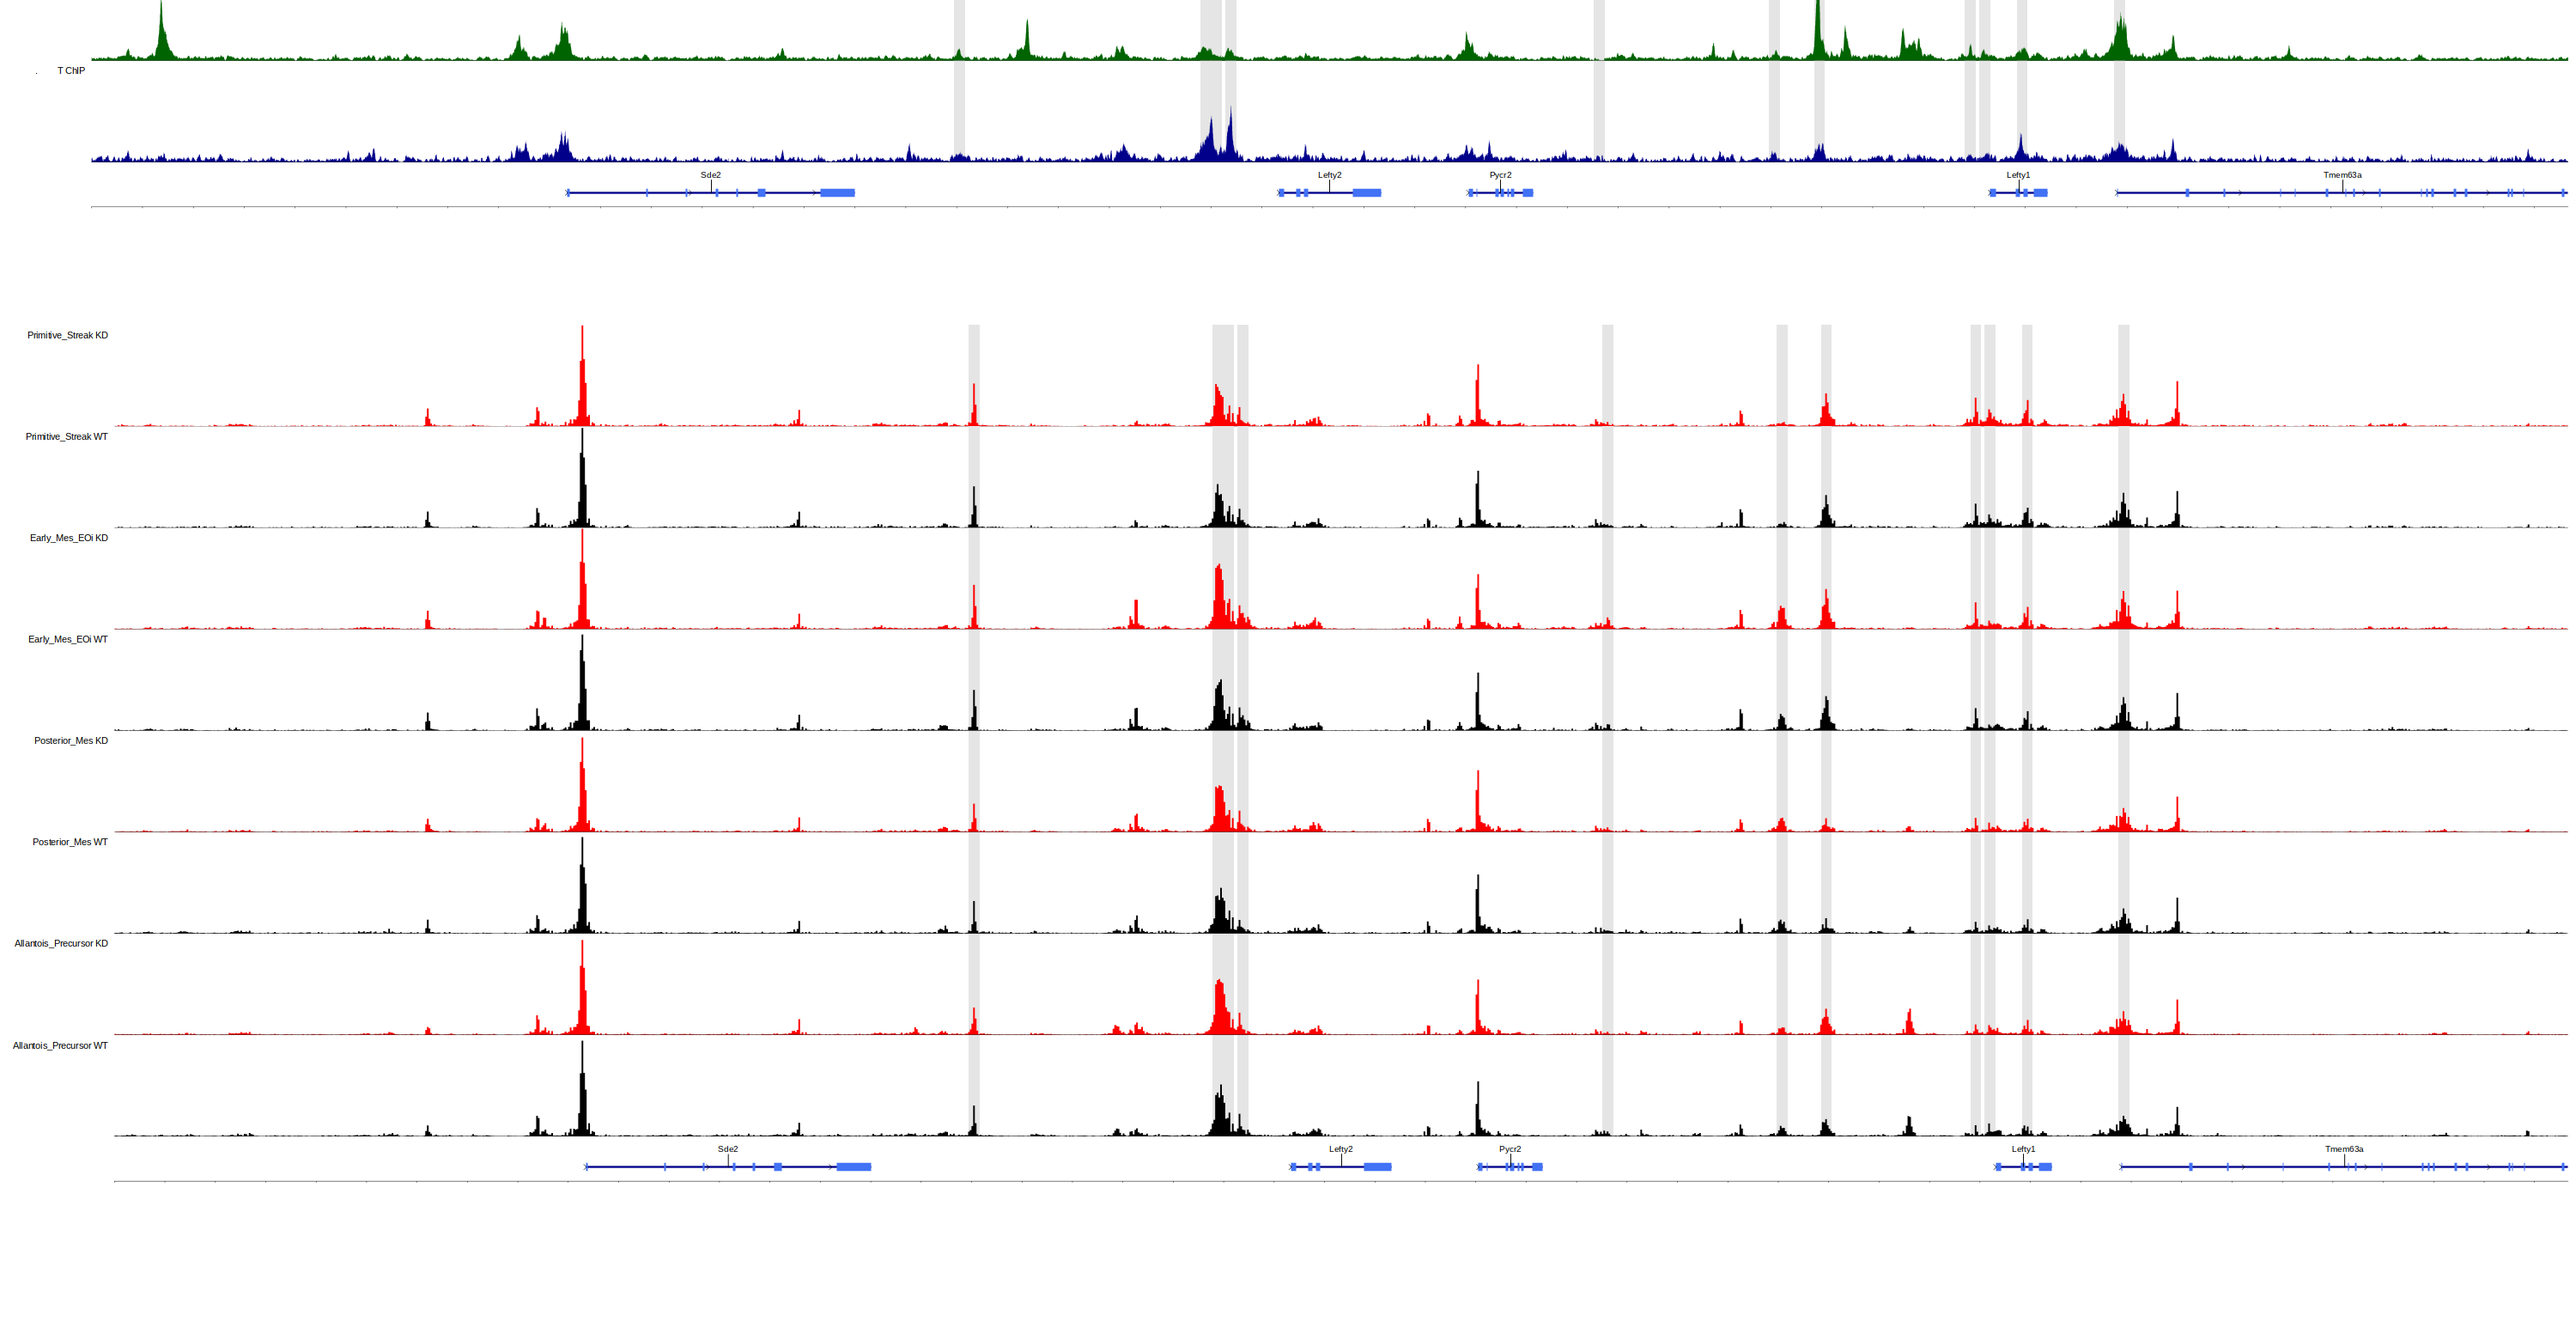

In [390]:
input_region = condRes[sig == T, gene]
extend = 7e4
options(repr.plot.width = 25, repr.plot.height = 13)
ggarrange(plot_browser_track(gene = 'Lefty2', # gene used for plotting expression
                              input_region = NULL, # Region used
                              bigwigs = WT_plot[1:2], 
                              extend.upstream = extend,
                              extend.downstream = extend, 
                              highlight_regions = input_region, #if(length(tmp1$peak)>0){tmp1$peak}else{NULL},
                              downsample.rate = 1, 
                              no_label = F, 
                              plot_expression = F,
                              background_color = 'white',
                              highlight_color = 'grey90',
                              bw_height = 25, 
                              gene_height = 10,
                              bw_width = 200,
                              expr_width = 0),

plot_browser_track(gene = 'Lefty2', # gene used for plotting expression
                              input_region = NULL, # Region used
                              bigwigs = WT_plot[3:10], 
                              extend.upstream = extend,
                              extend.downstream = extend, 
                              highlight_regions = input_region, #if(length(tmp1$peak)>0){tmp1$peak}else{NULL},
                              downsample.rate = 1, 
                              no_label = F, 
                              plot_expression = F,
                              background_color = 'white',
                              highlight_color = 'grey90',
                              bw_height = 25, 
                              gene_height = 10,
                              bw_width = 200,
                              expr_width = 0),
          ncol = 1, 
          heights = c(1, 7)
)

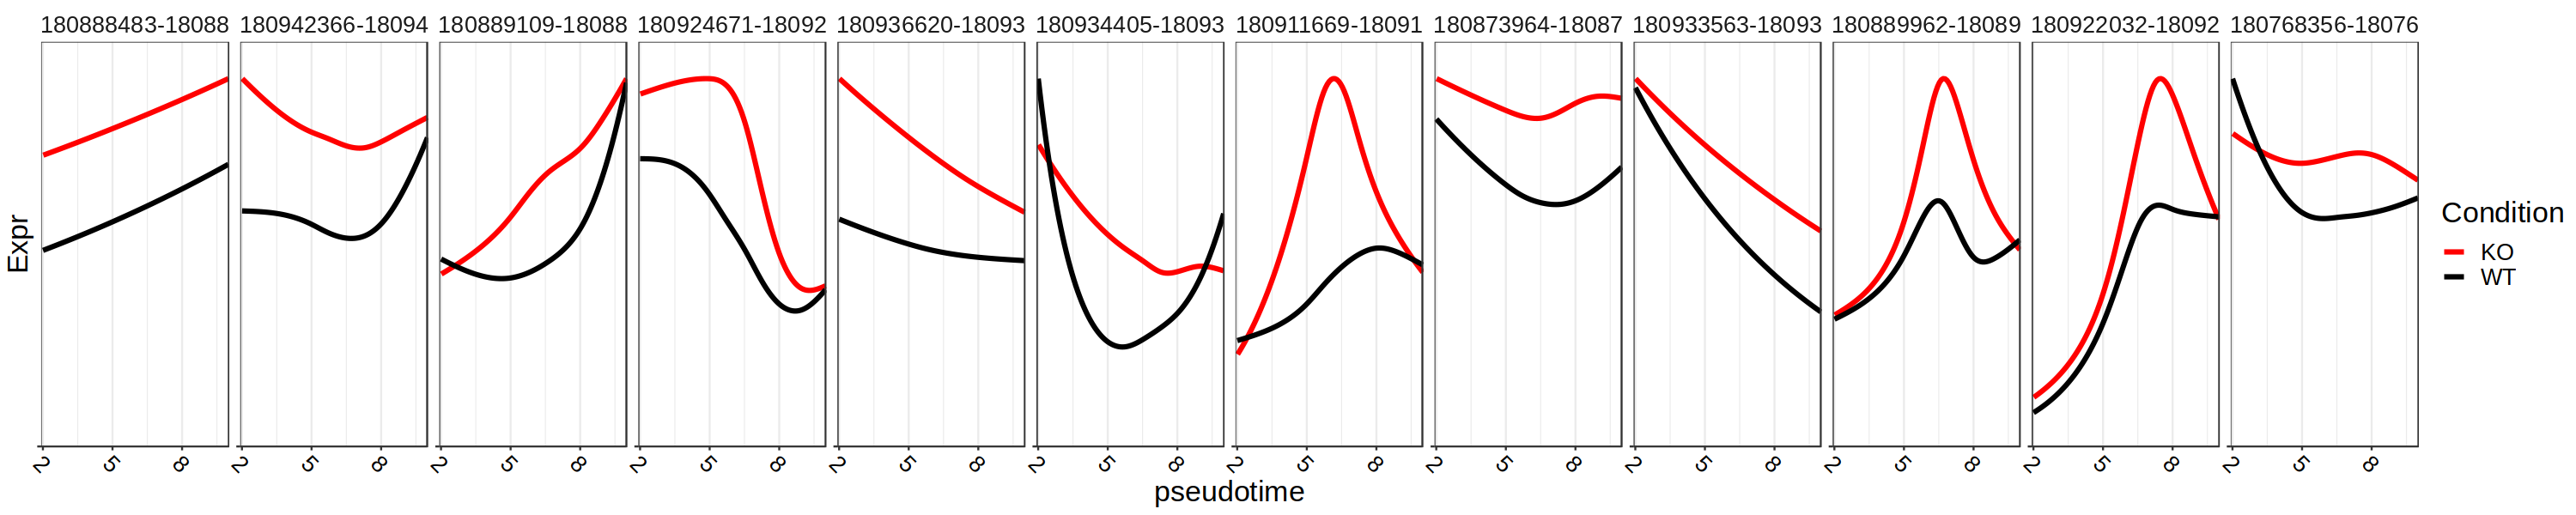

In [395]:
# Maybe just plot with predictSmooth values since they don't go below 0 so look a bit nicer
genes = test[gene == 'Lefty2' & sig == T, ] %>%
    .[order(peak)] %>% .$peak

yhatSmooth <- predictSmooth(sceGAM, gene = genes, nPoints = 100, tidy=TRUE)

RNA_filt.dt = as.data.table(yhatSmooth[yhatSmooth$gene %in% genes,]) %>% 
        setnames(c('lineage', 'time', 'yhat'), c('Traj', 'pseudotime', 'Expr')) %>%
        .[,gene:=factor(gene, levels = genes_keep)] %>%
        .[,Traj:=as.character(Traj)]

p = ggplot(RNA_filt.dt, aes(pseudotime, Expr, color=condition)) + 
    #    geom_point(size=0.2, alpha=0.2) +
        geom_line(linewidth = 1.3) + 
        scale_color_manual(values=c('KO'='red', 'WT'='black'), name='Condition') + 
        scale_x_continuous(expand=c(0.01,0, 0, 0), breaks=c(seq(2, 50, 3))) + 
        scale_y_continuous(expand=c(0,0, 0.1, 0), breaks=seq(0, 1e3, 3)) + 
    #    geom_smooth(se = F) +
        geom_hline(yintercept=0) +
        facet_wrap(~gene, ncol=12, scales='free_y') + 
        theme_bw() + 
        theme(strip.background = element_blank(),
              text = element_text(size=20),
              axis.text = element_text(color='black'),
              axis.text.x = element_text(angle=-45, hjust=0, vjust=1),
              axis.text.y = element_blank())

options(repr.plot.width = 25, repr.plot.height = 5)
p

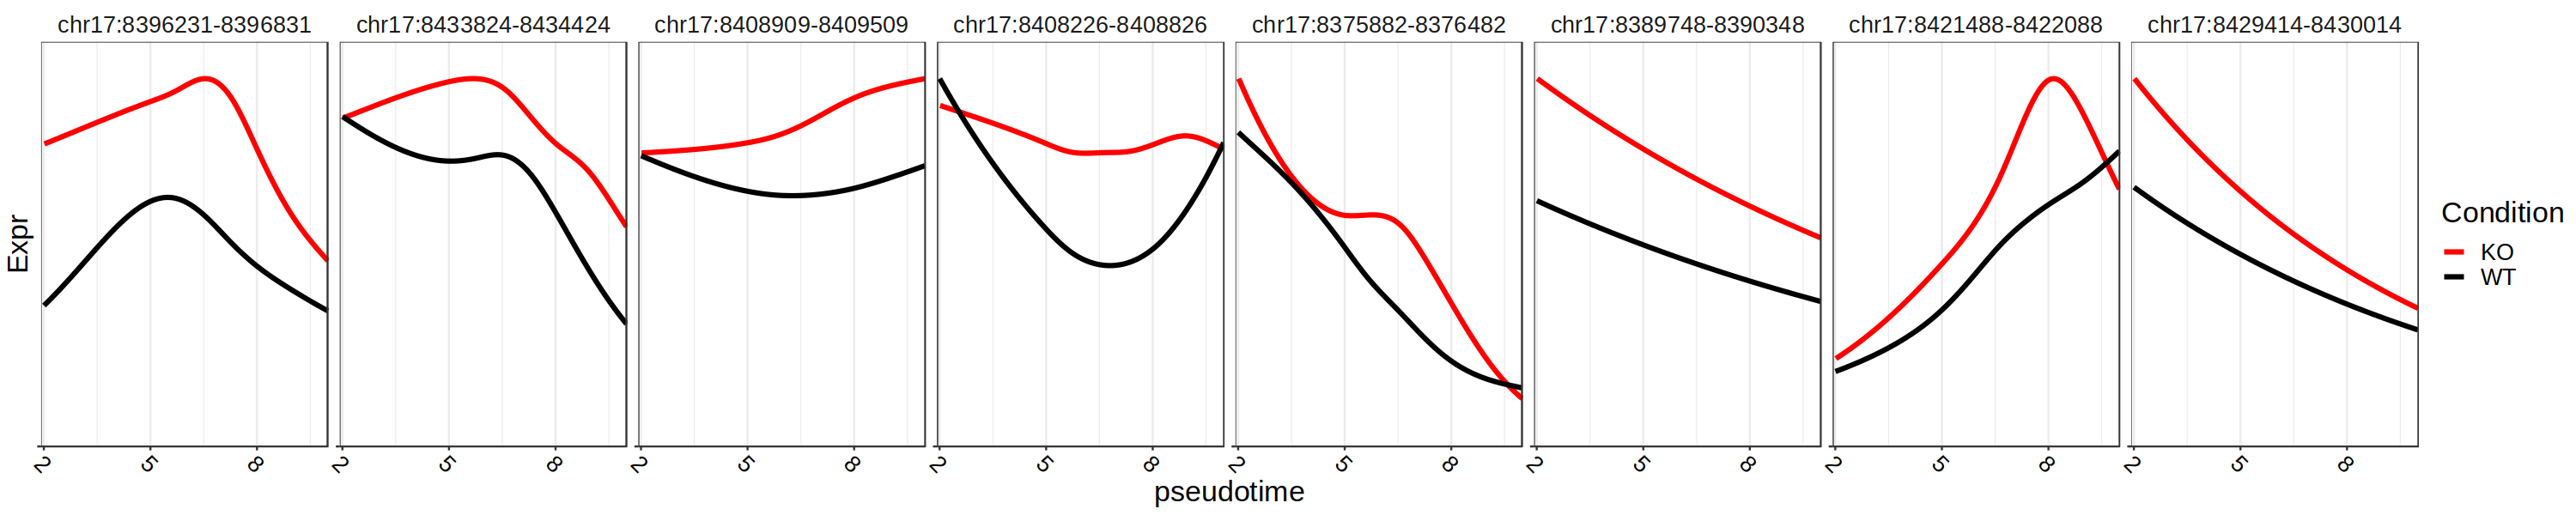

In [396]:
genes = test[gene == 'T' & sig == T, ] %>%
    .[order(peak)] %>% .$peak

yhatSmooth <- predictSmooth(sceGAM, gene = genes, nPoints = 100, tidy=TRUE)

RNA_filt.dt = as.data.table(yhatSmooth[yhatSmooth$gene %in% genes,]) %>% 
        setnames(c('lineage', 'time', 'yhat'), c('Traj', 'pseudotime', 'Expr')) %>%
        .[,gene:=factor(gene, levels = genes_keep)] %>%
        .[,Traj:=as.character(Traj)]

p = ggplot(RNA_filt.dt, aes(pseudotime, Expr, color=condition)) + 
    #    geom_point(size=0.2, alpha=0.2) +
        geom_line(linewidth = 1.3) + 
        scale_color_manual(values=c('KO'='red', 'WT'='black'), name='Condition') + 
        scale_x_continuous(expand=c(0.01,0, 0, 0), breaks=c(seq(2, 50, 3))) + 
        scale_y_continuous(expand=c(0,0, 0.1, 0), breaks=seq(0, 1e3, 3)) + 
    #    geom_smooth(se = F) +
        geom_hline(yintercept=0) +
        facet_wrap(~gene, ncol=12, scales='free_y') + 
        theme_bw() + 
        theme(strip.background = element_blank(),
              text = element_text(size=20),
              axis.text = element_text(color='black'),
              axis.text.x = element_text(angle=-45, hjust=0, vjust=1),
              axis.text.y = element_blank())

options(repr.plot.width = 25, repr.plot.height = 5)
p

peak,waldStat,df,pvalue,padj,sig,cor,pval,distance,gene,padj_linkage
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
chr11:85759907-85760507,10.37332,2,5.590648e-03,0.0383299252,TRUE,0.504,1.678224e-02,129856,Tbx4,8.576535e-02
chr11:85771404-85772004,11.84493,2,2.678590e-03,0.0227739591,TRUE,-0.721,1.522493e-04,118359,Tbx4,3.624476e-03
chr11:85774656-85775256,22.91991,5,3.496763e-04,0.0051272027,TRUE,-0.066,7.688435e-01,115107,Tbx4,8.818976e-01
chr11:85776233-85776833,17.47230,6,7.695559e-03,0.0480154719,TRUE,0.512,1.485481e-02,113530,Tbx4,7.909985e-02
chr11:85800360-85800960,15.15870,2,5.108920e-04,0.0067804877,TRUE,0.535,1.036580e-02,89403,Tbx4,6.235640e-02
chr11:85804037-85804637,34.55091,7,1.358104e-05,0.0004387214,TRUE,0.366,9.436137e-02,85726,Tbx4,2.611846e-01
chr11:85818158-85818758,22.38605,6,1.030469e-03,0.0114377526,TRUE,0.257,2.480775e-01,71605,Tbx4,4.718409e-01
chr11:85832337-85832937,23.57470,8,2.699686e-03,0.0228920066,TRUE,0.310,1.606522e-01,57426,Tbx4,3.630032e-01
chr11:85915861-85916461,15.28952,3,1.585225e-03,0.0156812248,TRUE,0.891,2.735991e-08,64,Tbx4,1.017524e-05


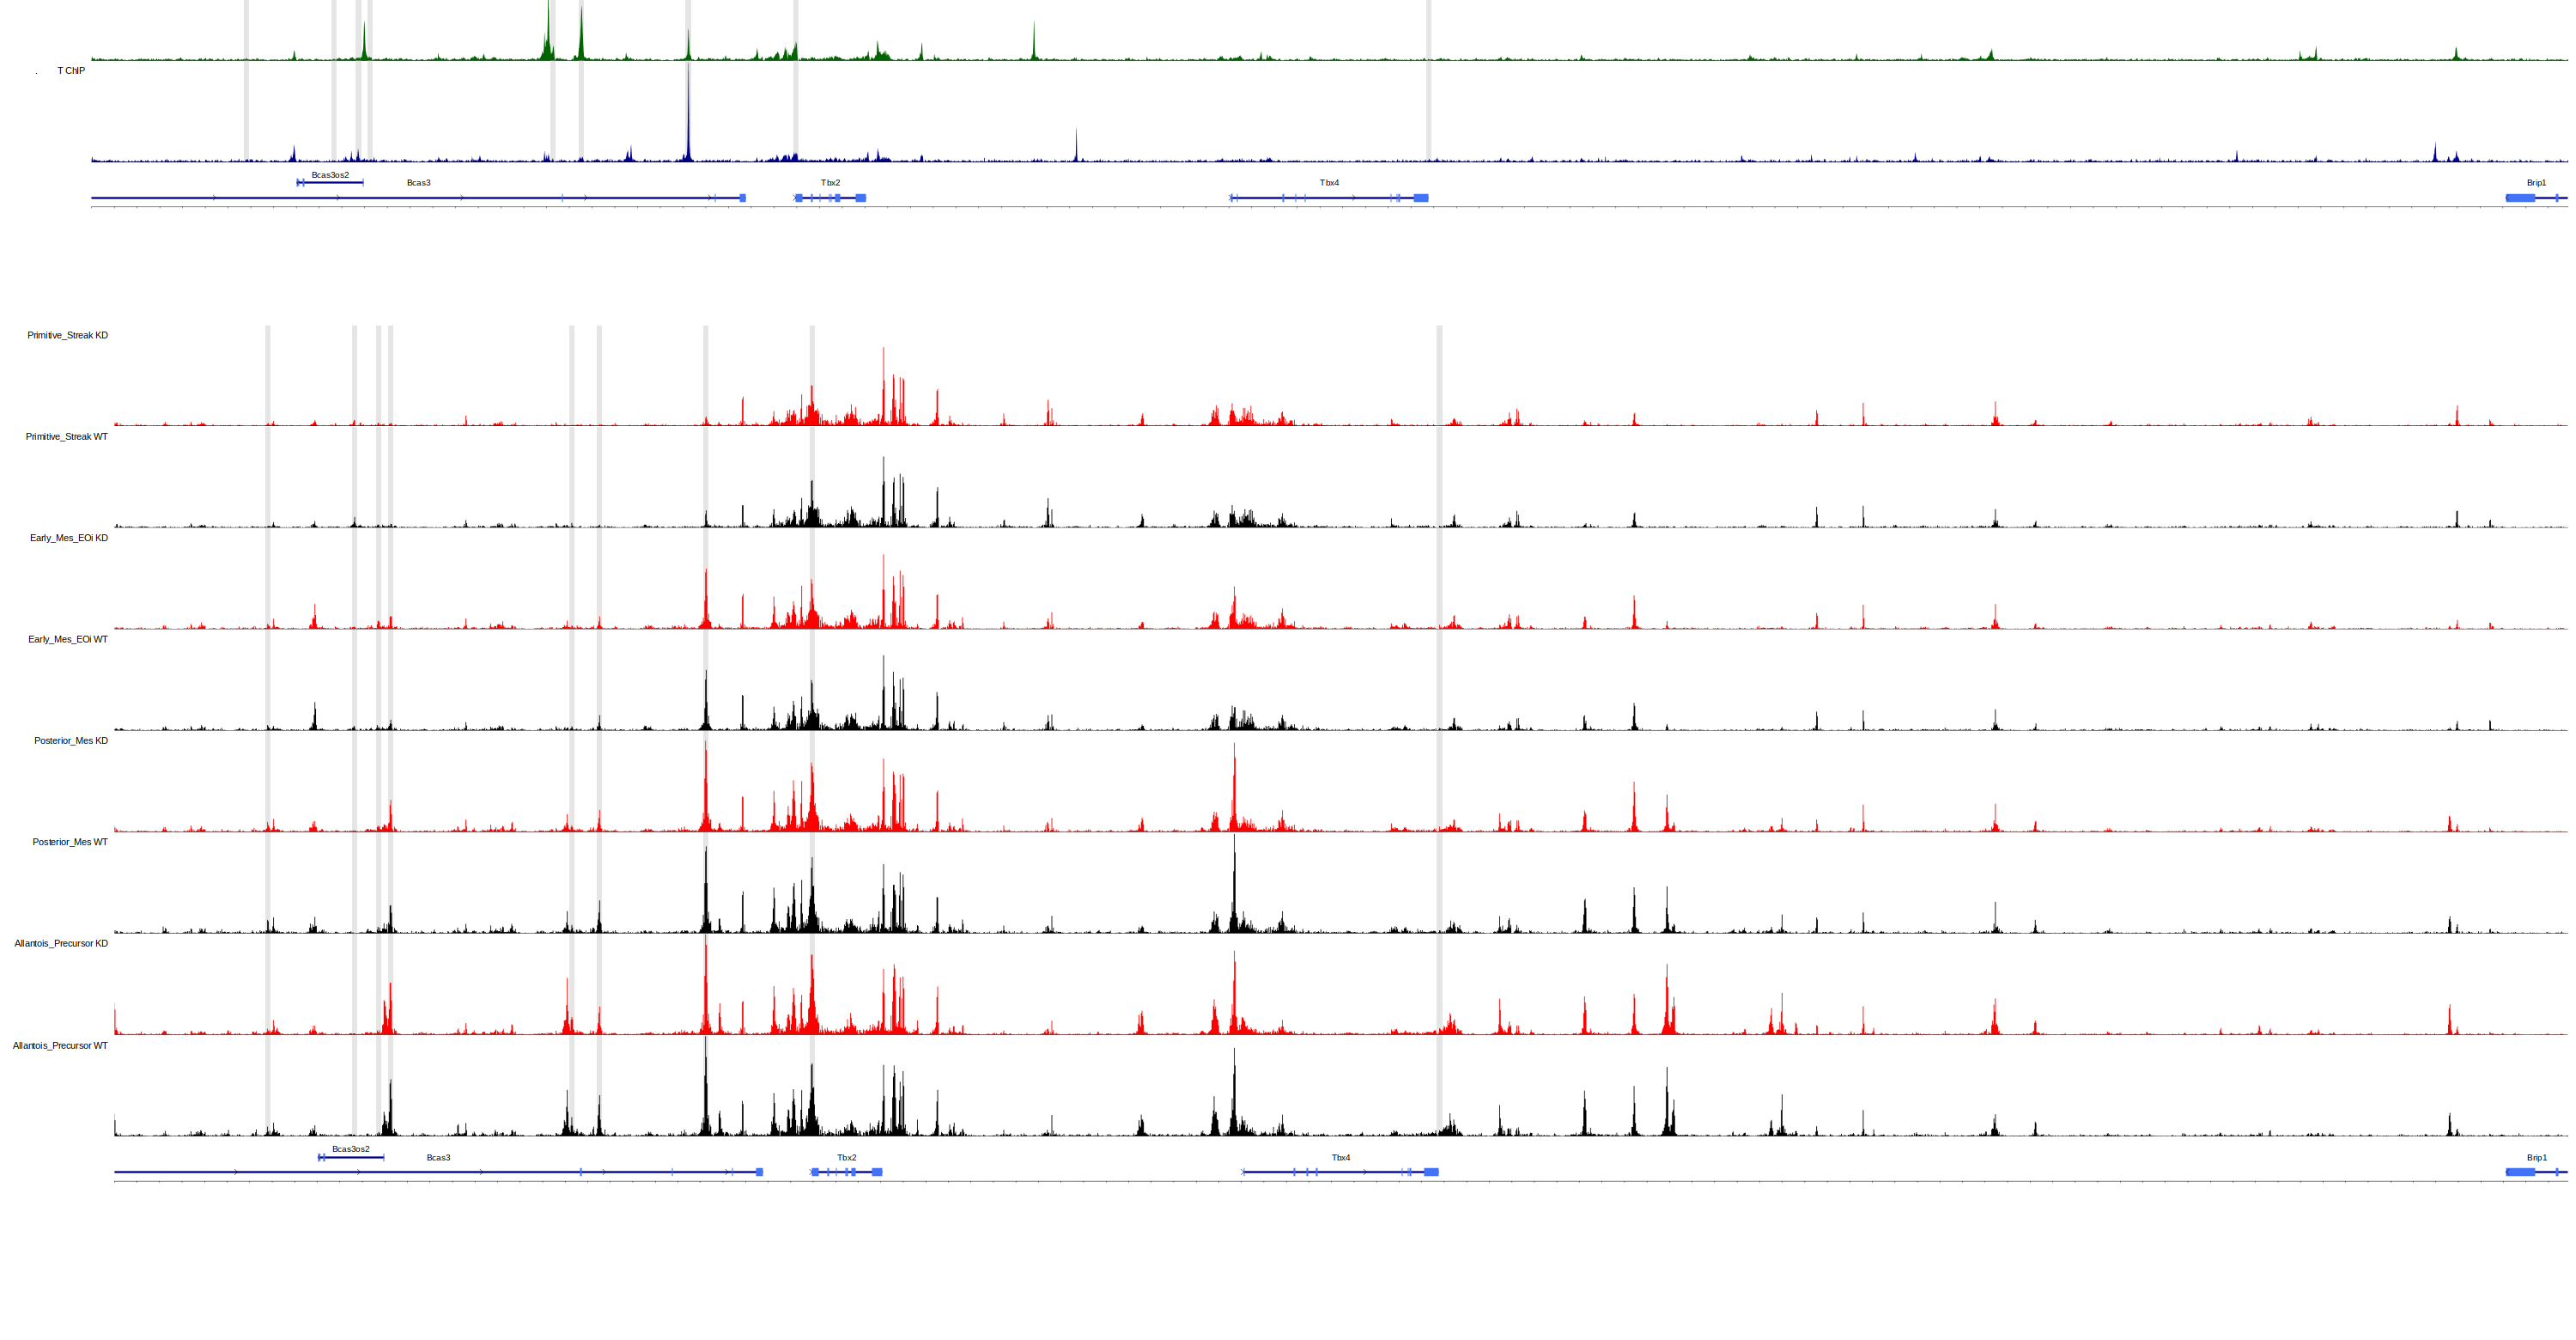

In [399]:
input_region = condRes[sig == T, gene]
gene = 'Tbx4'
extend = max(test[gene == gene, distance]) 
options(repr.plot.width = 25, repr.plot.height = 13)
ggarrange(plot_browser_track(gene = gene, # gene used for plotting expression
                              input_region = NULL, # Region used
                              bigwigs = WT_plot[1:2], 
                              extend.upstream = extend,
                              extend.downstream = extend, 
                              highlight_regions = input_region, #if(length(tmp1$peak)>0){tmp1$peak}else{NULL},
                              downsample.rate = 1, 
                              no_label = F, 
                              plot_expression = F,
                              background_color = 'white',
                              highlight_color = 'grey90',
                              bw_height = 25, 
                              gene_height = 10,
                              bw_width = 200,
                              expr_width = 0),

plot_browser_track(gene = gene, # gene used for plotting expression
                              input_region = NULL, # Region used
                              bigwigs = WT_plot[3:10], 
                              extend.upstream = extend,
                              extend.downstream = extend, 
                              highlight_regions = input_region, #if(length(tmp1$peak)>0){tmp1$peak}else{NULL},
                              downsample.rate = 1, 
                              no_label = F, 
                              plot_expression = F,
                              background_color = 'white',
                              highlight_color = 'grey90',
                              bw_height = 25, 
                              gene_height = 10,
                              bw_width = 200,
                              expr_width = 0),
          ncol = 1, 
          heights = c(1, 7)
)

### Plot heatmaps of Eomes & T ChIP signal surrounding differential peaks

In [25]:
chips = data.table(
    celltype = 'ChIP',
    genotype = '',
    path = c('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_bamCoverage_ChIP_EoGFP_dox.bigwig',
            '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_bamCoverage_ChIP_BraGFP_dox.bigwig',
            '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_bamCoverage_ChIP_EoGFP_nodox.bigwig',
            '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_bamCoverage_ChIP_BraGFP_nodox.bigwig'),
    name = c('Eomes ChIP', 'T ChIP', 'Eomes Ctrl', 'T Ctrl'),
    color = c('darkgreen', 'darkblue', 'grey90', 'grey95')
)
# group.dt = as.data.table(group, keep.rownames = T) %>% setnames('rn', 'region')
group.dt = fread(file.path(args$outdir, 'atac_groups.txt.gz'))
group = as.vector(group.dt$group)
names(group) = group.dt$region

In [26]:
input_region= rownames(WT)

order = input_region[unlist(row_order(hm_list))]

extend = 1000 # 1000
outlier = 0.98 # 0.95

gr <- GRanges(c(str_split(input_region, ":") %>% map_chr(1)), 
    IRanges(start = as.numeric(str_split(str_split(input_region, 
                        ":") %>% map_chr(2), "-") %>% map_chr(1)) - extend, 
            end = as.numeric(str_split(str_split(input_region, 
                      ":") %>% map_chr(2), "-") %>% map_chr(2)) +  extend), strand = "+")

gr

Warning message:
“The heatmap list has not been initialized. You might have different
results if you repeatedly execute this function, e.g. when
row_km/column_km was set. It is more suggested to do as `ht_list =
draw(ht_list); row_order(ht_list)`.”


GRanges object with 7040 ranges and 0 metadata columns:
         seqnames              ranges strand
            <Rle>           <IRanges>  <Rle>
     [1]     chr9   46912091-46914691      +
     [2]     chr1 180887483-180890083      +
     [3]    chr14   63358208-63360808      +
     [4]    chr14 121778637-121781237      +
     [5]    chr14   23901737-23904337      +
     ...      ...                 ...    ...
  [7036]    chr19   37994436-37997036      +
  [7037]     chr4 141336801-141339401      +
  [7038]     chr7 141147478-141150078      +
  [7039]     chr2 165200621-165203221      +
  [7040]     chr4 156062749-156065349      +
  -------
  seqinfo: 20 sequences from an unspecified genome; no seqlengths

In [43]:
plot_bigwig = function(file, background = NULL, rollmean = NULL, outlier = 0.98){
    bigwig = mclapply(input_region, function(x){
        input_region = x
        gr <- GRanges(c(str_split(input_region, ":") %>% map_chr(1)), 
        IRanges(start = as.numeric(str_split(str_split(input_region, 
                            ":") %>% map_chr(2), "-") %>% map_chr(1)) - extend, 
                end = as.numeric(str_split(str_split(input_region, 
                          ":") %>% map_chr(2), "-") %>% map_chr(2)) +  extend), strand = "+")

        tmp = as.data.table(rtracklayer::import.bw(con = file, which = gr, as = "NumericList")) %>%
            .[, combine := ((.I - 1) %/% 10) + 1] %>%
            .[, .(mean_value = mean(value)), 
                  by = combine] %>%
            .[, pos := (combine-nrow(.)/2 ) * 10] %>%
            .[, region := x] 
        
        if(!is.null(rollmean)){
            tmp = tmp[, rollingmean := frollmean(mean_value, n = rollmean, align = "center")] %>%
                    .[, rollingmean := fifelse(is.na(rollingmean), mean_value, rollingmean)] %>% 
                .[,mean_value := rollingmean] %>% .[, rollingmean := NULL]
        }
        
        if(!is.null(background)){
            bg = as.data.table(rtracklayer::import.bw(con = background, which = gr, as = "NumericList")) %>%
                .[, combine := ((.I - 1) %/% 10) + 1] %>%
                .[, .(mean_value_bg = mean(value)), 
                      by = combine] %>%
                .[, pos := (combine-nrow(.)/2 ) * 10] %>%
                .[, region := x]
            if(!is.null(rollmean)){
                bg = bg[, rollingmean := frollmean(mean_value_bg, n = rollmean, align = "center")] %>%
                    .[, rollingmean := fifelse(is.na(rollingmean), mean_value_bg, rollingmean)] %>% 
                    .[,mean_value_bg := rollingmean] %>% .[, rollingmean := NULL]
            }
            tmp = merge(tmp, bg, by = c('region', 'pos')) %>%
                .[, mean_value := mean_value - mean_value_bg]
        }
        return(tmp)
    }, mc.cores = 40) %>%
        rbindlist()

    bigwig = merge(bigwig, group.dt, by = 'region')
    bigwig = bigwig[,group := factor(group, levels = c(1,2,3,4,5))]
    bigwig = bigwig[,region := factor(region, levels = order)]
    bigwig = bigwig %>%
        .[,value_no_outlier := ifelse(mean_value > quantile(mean_value, outlier, na.rm = T), quantile(mean_value, outlier, na.rm = T), mean_value)] %>% 
        .[,value_no_outlier := ifelse(value_no_outlier < quantile(value_no_outlier, 1-outlier, na.rm = T), quantile(value_no_outlier, 1-outlier, na.rm = T), value_no_outlier)]
    
    
    p = ggplot(bigwig, aes(pos, region, fill = minmax(value_no_outlier))) + 
        ggrastr::rasterize(geom_tile(), dpi = 10000) +
        #geom_tile() +
         viridis::scale_fill_viridis() +#limits = c(0, max(bigwig$value_no_outlier))) + 
        #scale_fill_gradientn(colors = rev(rainbow(4)), values = c(0, 0.2, 0.5, 1)) + 
        scale_x_continuous(expand = c(0,0)) + 
        scale_y_discrete(expand = c(0,0)) + 
        xlab('distance to centre (bp)') +
        facet_grid(group ~ ., scales = 'free_y', space = 'free_y') + 
        theme_bw() + 
        theme(axis.text = element_text(color = 'black', size = 6),
              axis.title.x = element_text(size = 7),
              axis.text.y = element_blank(),
              axis.title.y = element_blank(),
              axis.ticks.y = element_blank(),
              strip.background = element_blank(),
              strip.text = element_blank(),
              panel.spacing.y = unit(0.5, "mm"), # Adjust the distance between columns
              plot.margin = unit(c(0,0,0,0), 'mm')
)
    return(p)
}

In [44]:
p1 = plot_bigwig(chips$path[1], chips$path[3])
p2 = plot_bigwig(chips$path[2], chips$path[4])
options(repr.plot.height=5, repr.plot.width=6)
#ggarrange(p1, p2, common.legend = T, legend = 'right')

In [29]:
T_bed = fread('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_Peaks_ChIP_BraGFP_pileup40.bed.gz') %>%
    setnames(c('chr', 'start','end', 'name'))
Eomes_bed = fread('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_Peaks_ChIP_EoGFP_pileup120.bed.gz') %>%
    setnames(c('chr', 'start','end', 'name'))

In [30]:
Eomes_gr = makeGRangesFromDataFrame(Eomes_bed)
T_gr = makeGRangesFromDataFrame(T_bed)

In [31]:
input_region= group.dt$region
gr <- GRanges(c(str_split(input_region, ":") %>% map_chr(1)), 
    IRanges(start = as.numeric(str_split(str_split(input_region, 
                        ":") %>% map_chr(2), "-") %>% map_chr(1)), 
            end = as.numeric(str_split(str_split(input_region, 
                      ":") %>% map_chr(2), "-") %>% map_chr(2))), strand = "+")

gr

GRanges object with 7040 ranges and 0 metadata columns:
         seqnames              ranges strand
            <Rle>           <IRanges>  <Rle>
     [1]     chr9   46913091-46913691      +
     [2]     chr1 180888483-180889083      +
     [3]    chr14   63359208-63359808      +
     [4]    chr14 121779637-121780237      +
     [5]    chr14   23902737-23903337      +
     ...      ...                 ...    ...
  [7036]    chr19   37995436-37996036      +
  [7037]     chr4 141337801-141338401      +
  [7038]     chr7 141148478-141149078      +
  [7039]     chr2 165201621-165202221      +
  [7040]     chr4 156063749-156064349      +
  -------
  seqinfo: 20 sequences from an unspecified genome; no seqlengths

In [41]:
overlap = data.table(region = input_region) %>%
    .[, Eomes_bound := ifelse(.I %in% queryHits(findOverlaps(gr, Eomes_gr, type = 'any', minoverlap = 100)), 'Bound', 'Not bound')] %>%
    .[, T_bound := ifelse(.I %in% queryHits(findOverlaps(gr, T_gr, type = 'any', minoverlap = 100)), 'Bound', 'Not bound')] %>% 
    melt(id.vars = 'region') %>%
    merge(., group.dt, by = 'region') %>% 
    .[,group := factor(group, levels = c(1,2,3,4,5))] %>% 
    .[,region := factor(region, levels = order)] %>%
    .[,variable := gsub('_', ' ', variable)]

options(repr.plot.height=5, repr.plot.width=2)
p3 = ggplot(overlap, aes(variable, region, fill = value)) + 
    ggrastr::rasterize(geom_tile(), dpi = 10000) +
    # geom_tile() + 
    facet_grid(group ~ ., scales = 'free_y', space = 'free_y') + 
    scale_fill_manual(values = c('Bound' = 'green', 'Not bound' = 'red')) + 
    scale_x_discrete(expand = c(0,0), position = 'top') + 
    scale_y_discrete(expand = c(0,0)) + 
    theme_bw() + 
    theme(axis.text = element_text(color = 'black', size = 6), 
          axis.text.y = element_blank(),
          axis.title.y = element_blank(),
          axis.title.x = element_blank(),
          axis.text.x = element_text(angle = 45, vjust = 0, hjust = 0),
          axis.ticks.y = element_blank(),
          panel.spacing.y = unit(0.5, "mm"), # Adjust the distance between columns
          strip.background = element_blank(),
          strip.text = element_blank(),
        plot.margin = unit(c(0,0,0,0), 'mm')
          )
#p3

In [38]:
fwrite(overlap, file.path(args$outdir, 'T_Eomes_overlap_DARs.txt.gz'))

In [33]:
overlap = data.table(region = input_region) %>%
    .[, Eomes_bound := ifelse(.I %in% queryHits(findOverlaps(gr, Eomes_gr, type = 'any', minoverlap = 100)), 'Bound', 'Not bound')] %>%
    .[, T_bound := ifelse(.I %in% queryHits(findOverlaps(gr, T_gr, type = 'any', minoverlap = 100)), 'Bound', 'Not bound')] %>% 
    melt(id.vars = 'region') %>%
    merge(., group.dt, by = 'region')

In [35]:
T_perc = overlap %>% copy() %>%
    .[variable == 'T_bound'] %>%
    .[, Ngroup := .N, by = 'group'] %>%
    # .[value := 'Bound'] %>%
    .[, perc := .N/Ngroup*100, by = c('group', 'value')] %>%
    unique(by = c('group', 'value')) %>%
    .[order(group, value)]
T_perc[,.(value, group, perc)]    

Eo_perc = overlap %>% copy() %>%
    .[variable == 'Eomes_bound'] %>%
    .[, Ngroup := .N, by = 'group'] %>%
    # .[value := 'Bound'] %>%
    .[, perc := .N/Ngroup*100, by = c('group', 'value')] %>%
    unique(by = c('group', 'value')) %>%
    .[order(group, value)]
Eo_perc[,.(value, group, perc)]    

value,group,perc
<chr>,<int>,<dbl>
Bound,1,13.93656
Not bound,1,86.06344
Bound,2,30.97713
Not bound,2,69.02287
Bound,3,59.97770
Not bound,3,40.02230
Bound,4,31.66999
Not bound,4,68.33001
Bound,5,13.56125


value,group,perc
<chr>,<int>,<dbl>
Bound,1,34.68539
Not bound,1,65.31461
Bound,2,35.86279
Not bound,2,64.13721
Bound,3,23.74582
Not bound,3,76.25418
Bound,4,21.29075
Not bound,4,78.70925
Bound,5,11.73789


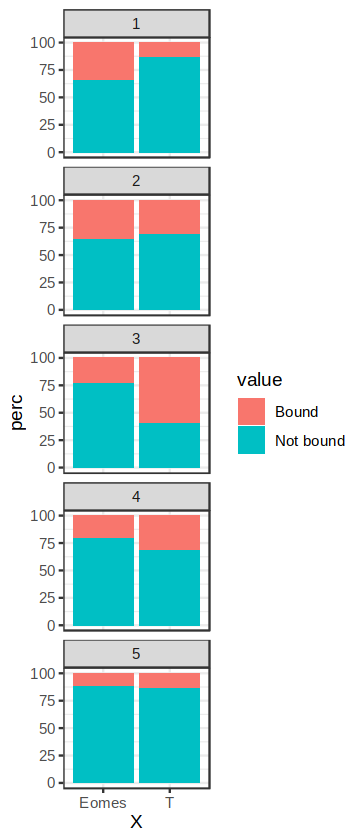

In [36]:
perc = rbind(T_perc[,X := 'T'], Eo_perc[,X := 'Eomes'])
options(repr.plot.height=7, repr.plot.width=3)
ggplot(perc, aes(X, perc, fill = value)) + 
    geom_bar(stat = 'identity') + 
    facet_wrap(~group, ncol = 1) + 
    theme_bw()

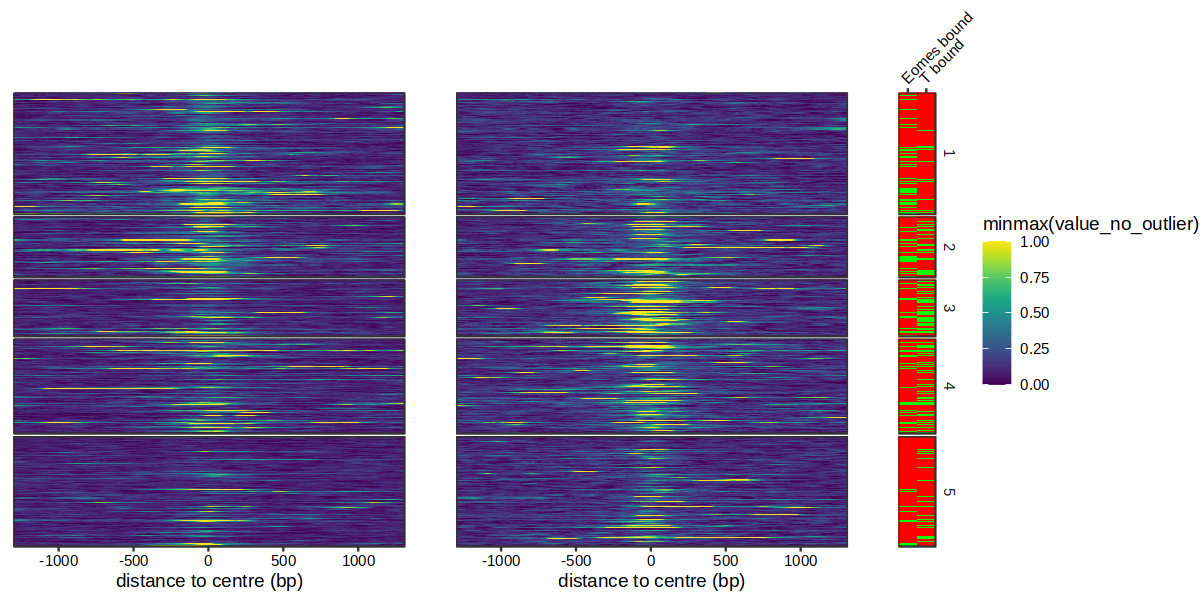

In [273]:
options(repr.plot.height=5, repr.plot.width=10)

ggarrange(p1, p2, p3, nrow = 1, widths = c(1,1,0.2), align = 'hv', common.legend = TRUE, legend = 'right')